In [172]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
from typing import Optional
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from typing import Iterable, Any, Dict, Iterable, Optional, Tuple, List

plt.rcParams.update({
    "font.size": 20,        # tamaño base
    "axes.titlesize": 24,   # título del gráfico
    "axes.labelsize": 22,   # labels de ejes
    "xtick.labelsize": 18,  # números eje X
    "ytick.labelsize": 18,  # números eje Y
    "legend.fontsize": 18,  # leyenda
    "figure.titlesize": 26  # título general de la figura
})

In [173]:
def validate_columns(
    df: pd.DataFrame,
    required_columns: Iterable[str],
) -> None:
    """
    Validate that all required columns exist in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    required_columns : Iterable[str]
        Required column names.

    Raises
    ------
    ValueError
        If one or more required columns are missing.
    """

    missing_columns = set(required_columns).difference(df.columns)

    if missing_columns:
        raise ValueError(
            "Missing required columns: "
            f"{', '.join(sorted(missing_columns))}"
        )


def add_galactic_coordinates(
    df: pd.DataFrame,
    ra_col: str = "ra",
    dec_col: str = "dec",
    copy: bool = True,
) -> pd.DataFrame:
    """
    Agrega coordenadas galácticas a un DataFrame tipo Gaia.

    La función toma coordenadas ecuatoriales ICRS:

        ra  = ascensión recta, en grados
        dec = declinación, en grados

    y las transforma a coordenadas galácticas:

        l = longitud galáctica, en grados
        b = latitud galáctica, en grados

    Además agrega versiones en radianes:

        l_rad
        b_rad

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada. Debe contener columnas con RA y Dec.

    ra_col : str, optional
        Nombre de la columna que contiene la ascensión recta en grados.
        Por defecto: "ra".

    dec_col : str, optional
        Nombre de la columna que contiene la declinación en grados.
        Por defecto: "dec".

    copy : bool, optional
        Si True, la función crea una copia del DataFrame y no modifica
        el original.

        Si False, modifica directamente el DataFrame original.

    Returns
    -------
    pd.DataFrame
        DataFrame con las columnas agregadas:

        - l      : longitud galáctica en grados
        - b      : latitud galáctica en grados
        - l_rad  : longitud galáctica transformada a radianes
        - b_rad  : latitud galáctica en radianes
    """

    # ============================================================
    # 1. Verificar que existan las columnas necesarias
    # ============================================================
    validate_columns(df, [ra_col, dec_col])

    # ============================================================
    # 2. Decidir si se trabaja sobre una copia o sobre el original
    # ============================================================
    result = df.copy() if copy else df

    # ============================================================
    # 3. Crear objeto SkyCoord en sistema ecuatorial ICRS
    # ============================================================

    # SkyCoord es una clase de astropy para manejar coordenadas astronómicas.
    # Aquí se construyen coordenadas usando:
    #   ra  = ascensión recta
    #   dec = declinación
    # Ambas están en grados, por eso se multiplica por u.deg.
    # frame="icrs" indica que las coordenadas originales están en el
    # sistema ecuatorial ICRS, que es el sistema usado usualmente por Gaia.
    coords = SkyCoord(
        ra=result[ra_col].to_numpy() * u.deg,
        dec=result[dec_col].to_numpy() * u.deg,
        frame="icrs",
    )

    # ============================================================
    # 4. Transformar coordenadas ICRS a coordenadas galácticas
    # ============================================================
    # coords.galactic convierte automáticamente de:
    #   RA, Dec
    # a:
    #   l, b
    # donde:
    #   l = longitud galáctica
    #   b = latitud galáctica
    galactic_coords = coords.galactic

    # ============================================================
    # 5. Guardar longitud y latitud galáctica en grados
    # ============================================================
    # galactic_coords.l.degree entrega la longitud galáctica en grados.
    # Normalmente l está en el rango:
    #   0° <= l < 360°
    result["l"] = galactic_coords.l.degree
    # galactic_coords.b.degree entrega la latitud galáctica en grados.
    # Normalmente b está en el rango:
    #   -90° <= b <= 90°
    result["b"] = galactic_coords.b.degree

    # ============================================================
    # 6. Crear versión en radianes de la longitud galáctica
    # ============================================================
    # Aquí ocurre algo importante:
    #   result["l"] - 180.0
    # Esto desplaza la longitud galáctica desde el rango usual:
    #   0° a 360°
    # hacia un rango centrado aproximadamente en cero:
    #   -180° a 180°
    # Luego np.radians convierte grados a radianes.
    # Ejemplos:
    #   l =   0° -> l_rad = radians(-180°)
    #   l = 180° -> l_rad = radians(0°)
    #   l = 360° -> l_rad = radians(180°)
    # Ojo: este l_rad NO es simplemente radians(l).
    # Es radians(l - 180).
    result["l_rad"] = np.radians(result["l"].to_numpy() - 180.0)

    # ============================================================
    # 7. Crear versión en radianes de la latitud galáctica
    # ============================================================
    # Aquí sí se convierte directamente b de grados a radianes.
    result["b_rad"] = np.radians(result["b"].to_numpy())
    # ============================================================
    # 8. Devolver DataFrame resultante
    # ============================================================
    # Devuelve el DataFrame con columnas nuevas:
    #   l
    #   b
    #   l_rad
    #   b_rad
    return result


def add_galactic_proper_motions(
    df: pd.DataFrame,
    ra_col: str = "ra",
    dec_col: str = "dec",
    pmra_col: str = "pmra",
    pmdec_col: str = "pmdec",
    copy: bool = True,
    include_mu_l: bool = False,
) -> pd.DataFrame:
    """
    Transforma movimientos propios desde coordenadas ecuatoriales ICRS
    a coordenadas galácticas.

    Gaia entrega normalmente:

        pmra  = mu_alpha * cos(dec)
        pmdec = mu_delta

    Es decir, `pmra` no es simplemente mu_alpha, sino que ya viene
    multiplicado por cos(dec). Esta es la convención estándar de Gaia.

    Esta función agrega al DataFrame:

        pm_l_cosb = mu_l * cos(b)
        pm_b      = mu_b

    donde:

        l = longitud galáctica
        b = latitud galáctica

    Opcionalmente también puede agregar:

        pm_l = mu_l

    pero para muchos análisis cinemáticos y de clustering suele ser mejor
    usar `pm_l_cosb`, porque es la componente tangencial bien comportada
    cerca de los polos galácticos.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada.

    ra_col : str, optional
        Nombre de la columna con ascensión recta, en grados.
        Por defecto: "ra".

    dec_col : str, optional
        Nombre de la columna con declinación, en grados.
        Por defecto: "dec".

    pmra_col : str, optional
        Nombre de la columna con movimiento propio en ascensión recta,
        usando la convención Gaia:

            pmra = mu_alpha * cos(dec)

        Debe estar en mas/yr.
        Por defecto: "pmra".

    pmdec_col : str, optional
        Nombre de la columna con movimiento propio en declinación.
        Debe estar en mas/yr.
        Por defecto: "pmdec".

    copy : bool, optional
        Si True, crea una copia del DataFrame y no modifica el original.

        Si False, modifica directamente el DataFrame original.

    include_mu_l : bool, optional
        Si True, también agrega la columna:

            pm_l = pm_l_cosb / cos(b)

        Por defecto es False.

    Returns
    -------
    pd.DataFrame
        DataFrame con columnas agregadas:

        - pm_l_cosb : movimiento propio en longitud galáctica multiplicado
                      por cos(b), en mas/yr.
        - pm_b      : movimiento propio en latitud galáctica, en mas/yr.
        - pm_l      : opcional, movimiento propio puro en longitud galáctica,
                      en mas/yr.
    """

    # ============================================================
    # 1. Definir columnas requeridas
    # ============================================================
    required_columns = [ra_col, dec_col, pmra_col, pmdec_col]

    # Verificar que esas columnas existan en el DataFrame.
    validate_columns(df, required_columns)

    # ============================================================
    # 2. Decidir si trabajar sobre copia o sobre el DataFrame original
    # ============================================================
    result = df.copy() if copy else df

    # ============================================================
    # 3. Crear objeto SkyCoord con posiciones y movimientos propios
    # ============================================================
    # Aquí le pasamos:
    #   ra  -> ascensión recta en grados
    #   dec -> declinación en grados
    # También le pasamos los movimientos propios:
    #   pm_ra_cosdec -> pmra de Gaia = mu_alpha * cos(dec)
    #   pm_dec       -> mu_delta
    # Las unidades se indican explícitamente:
    #   u.deg        -> grados
    #   u.mas / u.yr -> milisegundos de arco por año
    # frame="icrs" indica que las coordenadas originales están en
    # el sistema ecuatorial ICRS, usado normalmente por Gaia.
    coords = SkyCoord(
        ra=result[ra_col].to_numpy() * u.deg,
        dec=result[dec_col].to_numpy() * u.deg,
        pm_ra_cosdec=result[pmra_col].to_numpy() * u.mas / u.yr,
        pm_dec=result[pmdec_col].to_numpy() * u.mas / u.yr,
        frame="icrs",
    )

    # ============================================================
    # 4. Transformar de ICRS a coordenadas galácticas
    # ============================================================
    # Astropy transforma tanto la posición como los movimientos propios.
    # Pasa de:
    #   ra, dec, pmra, pmdec
    # a:
    #   l, b, pm_l_cosb, pm_b
    # donde:
    #   l = longitud galáctica
    #   b = latitud galáctica
    galactic_coords = coords.galactic

    # ============================================================
    # 5. Guardar movimiento propio en longitud galáctica
    # ============================================================
    # galactic_coords.pm_l_cosb es:
    #   pm_l_cosb = mu_l * cos(b)
    # Esto es análogo a la convención de Gaia:
    #   pmra = mu_alpha * cos(dec)
    # Se usa `.to_value(u.mas / u.yr)` para obtener solo los valores
    # numéricos en mas/yr, sin el objeto de unidad de astropy.
    result["pm_l_cosb"] = galactic_coords.pm_l_cosb.to_value(
        u.mas / u.yr
    )

    # ============================================================
    # 6. Guardar movimiento propio en latitud galáctica
    # ============================================================
    # galactic_coords.pm_b es:
    #   pm_b = mu_b
    # Es la componente del movimiento propio en dirección de la latitud
    # galáctica b.
    result["pm_b"] = galactic_coords.pm_b.to_value(u.mas / u.yr)

    # ============================================================
    # 7. Opcionalmente calcular pm_l sin el factor cos(b)
    # ============================================================
    # Por defecto no se calcula pm_l porque `pm_l_cosb` suele ser más estable
    # y más adecuado para análisis cinemáticos.
    # Pero si include_mu_l=True, se calcula:
    #   pm_l = pm_l_cosb / cos(b)
    if include_mu_l:

        # Obtener la latitud galáctica b en radianes.
        # Se usa radianes porque np.cos espera ángulos en radianes.
        b_rad = galactic_coords.b.to_value(u.rad)

        # Calcular cos(b).
        cos_b = np.cos(b_rad)

        # Calcular pm_l solo cuando cos(b) no sea demasiado pequeño.
        # np.where funciona así:
        #   si abs(cos_b) > 1e-12:
        #       pm_l = pm_l_cosb / cos_b
        #   si no:
        #       pm_l = NaN
        # Esto evita divisiones numéricamente peligrosas cerca de b = ±90°.
        result["pm_l"] = np.where(
            np.abs(cos_b) > 1e-12,
            result["pm_l_cosb"].to_numpy() / cos_b,
            np.nan,
        )

    # ============================================================
    # 8. Devolver DataFrame resultante
    # ============================================================
    # Devuelve el DataFrame con las columnas agregadas:
    #   pm_l_cosb
    #   pm_b
    # y, si include_mu_l=True:
    #   pm_l
    return result

In [174]:
MAS_TO_RAD = np.deg2rad(1.0 / 3_600_000.0)

In [175]:
def add_initial_final_galactic_vectors(
    df: pd.DataFrame,
    l_col: str = "l",
    b_col: str = "b",
    pm_l_col: str = "pm_l_cosb",
    pm_b_col: str = "pm_b",
    time_years: float = 1.0,
    angles_in_degrees: bool = True,
    pm_l_is_cosb: bool = True,
    copy: bool = True,
) -> pd.DataFrame:
    """
    Agrega vectores cartesianos galácticos iniciales y finales.

    Esta función toma la posición galáctica de cada estrella:

        l = longitud galáctica
        b = latitud galáctica

    junto con sus movimientos propios galácticos:

        pm_l_cosb = mu_l * cos(b)
        pm_b      = mu_b

    y calcula dos direcciones 3D unitarias:

        [x_initial, y_initial, z_initial]
        [x_final,   y_final,   z_final]

    La posición inicial se calcula como:

        x_initial = cos(l) * cos(b)
        y_initial = sin(l) * cos(b)
        z_initial = sin(b)

    La posición final se calcula desplazando angularmente la estrella
    según su movimiento propio durante un intervalo `time_years`:

        l_final = l + delta_l
        b_final = b + delta_b

    donde:

        delta_l = mu_l * time_years
        delta_b = mu_b * time_years

    Como los movimientos propios vienen en mas/yr, primero se convierten
    de milisegundos de arco a radianes.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada.

    l_col : str, optional
        Nombre de la columna con longitud galáctica.
        Por defecto: "l".

    b_col : str, optional
        Nombre de la columna con latitud galáctica.
        Por defecto: "b".

    pm_l_col : str, optional
        Nombre de la columna con movimiento propio en longitud galáctica.

        Por defecto: "pm_l_cosb".

        Si `pm_l_is_cosb=True`, esta columna se interpreta como:

            pm_l_cosb = mu_l * cos(b)

        Si `pm_l_is_cosb=False`, esta columna se interpreta directamente como:

            mu_l

    pm_b_col : str, optional
        Nombre de la columna con movimiento propio en latitud galáctica.
        Por defecto: "pm_b".

    time_years : float, optional
        Intervalo de tiempo usado para propagar la posición.
        Debe estar en años.

        Por defecto: 1.0.

    angles_in_degrees : bool, optional
        Si True, las columnas `l` y `b` se interpretan en grados.

        Si False, se interpretan en radianes.

    pm_l_is_cosb : bool, optional
        Si True, `pm_l_col` contiene:

            pm_l_cosb = mu_l * cos(b)

        y la función calcula:

            mu_l = pm_l_cosb / cos(b)

        Si False, `pm_l_col` ya contiene directamente `mu_l`.

    copy : bool, optional
        Si True, devuelve una copia modificada del DataFrame.

        Si False, modifica directamente el DataFrame original.

    Returns
    -------
    pd.DataFrame
        DataFrame con columnas agregadas:

        - x_initial
        - y_initial
        - z_initial
        - x_final
        - y_final
        - z_final
        - delta_l_rad
        - delta_b_rad
        - l_final_rad
        - b_final_rad

    Raises
    ------
    ValueError
        Si faltan columnas requeridas.

        También lanza ValueError si `pm_l_is_cosb=True` y alguna estrella
        tiene cos(b) demasiado cercano a cero, porque no se puede calcular
        de forma segura:

            mu_l = pm_l_cosb / cos(b)
    """

    # ============================================================
    # 1. Verificar columnas necesarias
    # ============================================================
    # Si falta alguna, validate_columns debería lanzar un error claro.
    validate_columns(df, [l_col, b_col, pm_l_col, pm_b_col])

    # ============================================================
    # 2. Decidir si modificar copia o DataFrame original
    # ============================================================
    result = df.copy() if copy else df

    # ============================================================
    # 3. Convertir l y b a radianes
    # ============================================================
    # Las funciones trigonométricas de NumPy:
    #   np.sin
    #   np.cos
    # esperan ángulos en radianes.
    if angles_in_degrees:
        l_rad = np.deg2rad(result[l_col].to_numpy(dtype=float))
        b_rad = np.deg2rad(result[b_col].to_numpy(dtype=float))
    else:
        # Si ya vienen en radianes, solo las extraemos como arrays NumPy.
        l_rad = result[l_col].to_numpy(dtype=float)
        b_rad = result[b_col].to_numpy(dtype=float)

    # ============================================================
    # 4. Extraer movimientos propios
    # ============================================================
    # Movimiento propio en longitud galáctica.
    # Puede ser:
    #   pm_l_cosb = mu_l * cos(b)
    # o directamente:
    #   mu_l
    # dependiendo del parámetro pm_l_is_cosb.
    pm_l_values = result[pm_l_col].to_numpy(dtype=float)

    # Movimiento propio en latitud galáctica.
    # Se interpreta como:
    #   mu_b
    pm_b_values = result[pm_b_col].to_numpy(dtype=float)

    # ============================================================
    # 5. Calcular cos(b)
    # ============================================================
    # cos(b) se necesita porque muchas veces el movimiento en longitud
    # galáctica viene guardado como:
    #   pm_l_cosb = mu_l * cos(b)
    # Para recuperar mu_l hay que dividir por cos(b).
    cos_b = np.cos(b_rad)

    # ============================================================
    # 6. Recuperar mu_l si pm_l_col contiene pm_l_cosb
    # ============================================================

    if pm_l_is_cosb:
        # Cerca de los polos galácticos:
        #   b ≈ +90°
        #   b ≈ -90°
        # se cumple:
        #   cos(b) ≈ 0
        # Entonces dividir por cos(b) sería numéricamente peligroso.
        near_galactic_pole = np.abs(cos_b) < 1e-12

        # Si alguna fuente está demasiado cerca del polo galáctico,
        # detenemos la función para evitar valores absurdamente grandes.
        if near_galactic_pole.any():
            raise ValueError(
                "Some sources have cos(b) too close to zero. "
                "Cannot safely compute mu_l = pm_l_cosb / cos(b)."
            )

        # Como:
        #   pm_l_cosb = mu_l * cos(b)
        # entonces:
        #   mu_l = pm_l_cosb / cos(b)
        mu_l_masyr = pm_l_values / cos_b

    else:
        # Si pm_l_is_cosb=False, asumimos que pm_l_values ya contiene mu_l.
        mu_l_masyr = pm_l_values

    # El movimiento en latitud galáctica ya es directamente mu_b.
    mu_b_masyr = pm_b_values

    # ============================================================
    # 7. Convertir desplazamientos angulares a radianes
    # ============================================================
    # Los movimientos propios están en:
    #   mas / yr
    # donde mas significa:
    #   milliarcsecond = milisegundo de arco
    # Para propagar durante time_years:
    #   delta_l = mu_l * time_years
    #   delta_b = mu_b * time_years
    # Pero necesitamos esos desplazamientos en radianes.
    # MAS_TO_RAD debe ser una constante que convierte:
    #   mas -> radianes
    # Por ejemplo:
    #   MAS_TO_RAD = np.deg2rad(1.0 / 3_600_000.0)
    # porque:
    #   1 grado = 3600 arcsec
    #   1 arcsec = 1000 mas
    #   1 grado = 3_600_000 mas
    delta_l_rad = mu_l_masyr * MAS_TO_RAD * time_years
    delta_b_rad = mu_b_masyr * MAS_TO_RAD * time_years

    # ============================================================
    # 8. Calcular posición final angular
    # ============================================================
    # Posición final en longitud galáctica:
    l_final_rad = l_rad + delta_l_rad

    # Posición final en latitud galáctica:
    b_final_rad = b_rad + delta_b_rad

    # ============================================================
    # 9. Convertir posición inicial a vector cartesiano unitario
    # ============================================================

    # Conversión esférica a cartesiana:
    # Esto produce un vector unitario sobre la esfera.
    result["x_initial"] = np.cos(l_rad) * np.cos(b_rad)
    result["y_initial"] = np.sin(l_rad) * np.cos(b_rad)
    result["z_initial"] = np.sin(b_rad)

    # ============================================================
    # 10. Convertir posición final a vector cartesiano unitario
    # ============================================================

    # Se usa la misma fórmula, pero ahora con:
    #   l_final_rad
    #   b_final_rad
    result["x_final"] = np.cos(l_final_rad) * np.cos(b_final_rad)
    result["y_final"] = np.sin(l_final_rad) * np.cos(b_final_rad)
    result["z_final"] = np.sin(b_final_rad)

    # ============================================================
    # 11. Guardar desplazamientos angulares
    # ============================================================

    # Desplazamiento en longitud galáctica, en radianes.
    result["delta_l_rad"] = delta_l_rad

    # Desplazamiento en latitud galáctica, en radianes.
    result["delta_b_rad"] = delta_b_rad

    # ============================================================
    # 12. Guardar coordenadas finales angulares
    # ============================================================

    # Longitud galáctica final, en radianes.
    result["l_final_rad"] = l_final_rad

    # Latitud galáctica final, en radianes.
    result["b_final_rad"] = b_final_rad

    # ============================================================
    # 13. Devolver DataFrame resultante
    # ============================================================
    return result

In [176]:
def add_cross_product_poles(
    df: pd.DataFrame,
    x_initial_col: str = "x_initial",
    y_initial_col: str = "y_initial",
    z_initial_col: str = "z_initial",
    x_final_col: str = "x_final",
    y_final_col: str = "y_final",
    z_final_col: str = "z_final",
    normalize: bool = True,
    copy: bool = True,
) -> pd.DataFrame:
    """
    Calcula los vectores polo usando el producto cruz entre la posición
    inicial y la posición final de cada estrella.

    Para cada estrella se tienen dos vectores cartesianos unitarios:

        r_initial = [x_initial, y_initial, z_initial]
        r_final   = [x_final,   y_final,   z_final]

    Esta función calcula:

        pole = r_initial x r_final

    donde "x" representa el producto cruz.

    Interpretación geométrica
    -------------------------
    Los vectores `r_initial` y `r_final` definen un plano que pasa por
    el origen de la esfera celeste.

    La intersección de ese plano con la esfera define un círculo máximo.

    El vector `pole` es perpendicular a ese plano, por lo tanto es el
    polo del círculo máximo asociado al movimiento de la estrella.

    En otras palabras:

        pole ⟂ r_initial
        pole ⟂ r_final

    Si `normalize=True`, la función también calcula la versión unitaria
    del polo:

        pole_unit = pole / ||pole||

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada. Debe contener columnas con los vectores
        cartesianos iniciales y finales.

    x_initial_col : str, optional
        Nombre de la columna con la componente x inicial.
        Por defecto: "x_initial".

    y_initial_col : str, optional
        Nombre de la columna con la componente y inicial.
        Por defecto: "y_initial".

    z_initial_col : str, optional
        Nombre de la columna con la componente z inicial.
        Por defecto: "z_initial".

    x_final_col : str, optional
        Nombre de la columna con la componente x final.
        Por defecto: "x_final".

    y_final_col : str, optional
        Nombre de la columna con la componente y final.
        Por defecto: "y_final".

    z_final_col : str, optional
        Nombre de la columna con la componente z final.
        Por defecto: "z_final".

    normalize : bool, optional
        Si True, además de guardar el polo original, guarda también
        el polo normalizado:

            pole_x_unit
            pole_y_unit
            pole_z_unit

        Si False, solo guarda:

            pole_x
            pole_y
            pole_z
            pole_norm

    copy : bool, optional
        Si True, devuelve una copia modificada del DataFrame.

        Si False, modifica directamente el DataFrame original.

    Returns
    -------
    pd.DataFrame
        DataFrame con columnas agregadas:

        - pole_x
        - pole_y
        - pole_z
        - pole_norm

        Si normalize=True, también agrega:

        - pole_x_unit
        - pole_y_unit
        - pole_z_unit
    """

    # ============================================================
    # 1. Definir columnas requeridas
    # ============================================================

    # Para calcular el producto cruz necesitamos dos vectores 3D:
    #
    #   r_initial = [x_initial, y_initial, z_initial]
    #   r_final   = [x_final,   y_final,   z_final]
    #
    # Por lo tanto necesitamos las seis columnas siguientes.
    required_columns = [
        x_initial_col,
        y_initial_col,
        z_initial_col,
        x_final_col,
        y_final_col,
        z_final_col,
    ]

    # Verifica que todas las columnas requeridas existan en el DataFrame.
    #
    # Si falta alguna columna, validate_columns debería lanzar un error claro.
    validate_columns(df, required_columns)

    # ============================================================
    # 2. Decidir si trabajar sobre copia o sobre el DataFrame original
    # ============================================================

    # Si copy=True:
    #     se crea una copia y el DataFrame original no se modifica.
    #
    # Si copy=False:
    #     result apunta al mismo DataFrame original y se modifica in-place.
    result = df.copy() if copy else df

    # ============================================================
    # 3. Extraer vectores iniciales
    # ============================================================

    # Se extraen las columnas:
    #
    #   x_initial
    #   y_initial
    #   z_initial
    #
    # y se convierten a un array NumPy.
    #
    # Forma esperada:
    #
    #   initial_vectors.shape == (n_estrellas, 3)
    #
    # Cada fila representa la posición inicial de una estrella:
    #
    #   [x_initial, y_initial, z_initial]
    initial_vectors = result[
        [x_initial_col, y_initial_col, z_initial_col]
    ].to_numpy(dtype=float)

    # ============================================================
    # 4. Extraer vectores finales
    # ============================================================

    # Se extraen las columnas:
    #
    #   x_final
    #   y_final
    #   z_final
    #
    # y se convierten a un array NumPy.
    #
    # Forma esperada:
    #
    #   final_vectors.shape == (n_estrellas, 3)
    #
    # Cada fila representa la posición final de una estrella:
    #
    #   [x_final, y_final, z_final]
    final_vectors = result[
        [x_final_col, y_final_col, z_final_col]
    ].to_numpy(dtype=float)

    # ============================================================
    # 5. Calcular producto cruz
    # ============================================================

    # np.cross calcula el producto cruz fila por fila.
    #
    # Para cada estrella:
    #
    #   pole_i = r_initial_i x r_final_i
    #
    # Si:
    #
    #   r_initial = [x1, y1, z1]
    #   r_final   = [x2, y2, z2]
    #
    # entonces:
    #
    #   pole = [
    #       y1*z2 - z1*y2,
    #       z1*x2 - x1*z2,
    #       x1*y2 - y1*x2
    #   ]
    #
    # El resultado tiene forma:
    #
    #   pole_vectors.shape == (n_estrellas, 3)
    #
    # Cada fila es:
    #
    #   [pole_x, pole_y, pole_z]
    pole_vectors = np.cross(initial_vectors, final_vectors)

    # ============================================================
    # 6. Guardar componentes del vector polo
    # ============================================================

    # Primera componente del producto cruz.
    result["pole_x"] = pole_vectors[:, 0]

    # Segunda componente del producto cruz.
    result["pole_y"] = pole_vectors[:, 1]

    # Tercera componente del producto cruz.
    result["pole_z"] = pole_vectors[:, 2]

    # ============================================================
    # 7. Calcular norma del vector polo
    # ============================================================

    # La norma del polo es:
    #
    #   ||pole|| = sqrt(pole_x^2 + pole_y^2 + pole_z^2)
    #
    # Si los vectores inicial y final son unitarios, esta norma también
    # tiene una interpretación geométrica:
    #
    #   ||r_initial x r_final|| = sin(theta)
    #
    # donde theta es el ángulo entre r_initial y r_final.
    #
    # Si theta es muy pequeño, el producto cruz será muy pequeño.
    pole_norm = np.linalg.norm(pole_vectors, axis=1)

    # Guardar la norma del polo.
    result["pole_norm"] = pole_norm

    # ============================================================
    # 8. Normalizar polos, si se solicita
    # ============================================================

    if normalize:

        # Identificar qué polos tienen norma mayor que cero.
        #
        # Solo estos se pueden normalizar.
        #
        # Si pole_norm == 0, significa que:
        #
        #   r_initial y r_final son paralelos o idénticos
        #
        # En ese caso el producto cruz es [0, 0, 0] y no tiene dirección.
        valid_norm = pole_norm > 0.0

        # Crear un array del mismo tamaño que pole_vectors,
        # inicialmente lleno de NaN.
        #
        # Usamos NaN para marcar las filas donde no se pudo calcular
        # un polo unitario.
        normalized_poles = np.full_like(pole_vectors, np.nan)

        # Normalizar solo los polos válidos.
        #
        # Para cada polo válido:
        #
        #   pole_unit = pole / ||pole||
        #
        # pole_norm[valid_norm, None] convierte las normas desde forma:
        #
        #   (n_validos,)
        #
        # a forma:
        #
        #   (n_validos, 1)
        #
        # para que NumPy pueda dividir cada fila por su propia norma.
        normalized_poles[valid_norm] = (
            pole_vectors[valid_norm] / pole_norm[valid_norm, None]
        )

        # Guardar componente x del polo unitario.
        result["pole_x_unit"] = normalized_poles[:, 0]

        # Guardar componente y del polo unitario.
        result["pole_y_unit"] = normalized_poles[:, 1]

        # Guardar componente z del polo unitario.
        result["pole_z_unit"] = normalized_poles[:, 2]

    # ============================================================
    # 9. Devolver DataFrame resultante
    # ============================================================

    # Devuelve el DataFrame con:
    #
    #   pole_x
    #   pole_y
    #   pole_z
    #   pole_norm
    #
    # y, si normalize=True:
    #
    #   pole_x_unit
    #   pole_y_unit
    #   pole_z_unit
    return result

In [177]:
def unit_vector_to_galactic_lb(vector: np.ndarray) -> Dict[str, float]:
    """
    Convierte un vector 3D en coordenadas galácticas:
    
        vector = [x, y, z]
    
    a longitud galáctica l y latitud galáctica b.

    Supone que el vector está en un sistema cartesiano galáctico:
    
        x apunta hacia l = 0°, b = 0°
        y apunta hacia l = 90°, b = 0°
        z apunta hacia b = 90°
    """

    # Convierte la entrada a un array NumPy de tipo float.
    # Esto permite aceptar listas, tuplas o arrays.
    #
    # Ejemplo:
    # vector = [1, 2, 3]
    # pasa a:
    # array([1.0, 2.0, 3.0])
    vector = np.asarray(vector, dtype=float)

    # Calcula la norma euclidiana del vector:
    # Sirve para saber cuánto mide el vector.
    norm = np.linalg.norm(vector)

    # Si la norma es cero, el vector es [0, 0, 0].
    # Ese vector no tiene dirección, por lo tanto no se puede convertir
    # a coordenadas angulares.
    if norm == 0.0:
        raise ValueError("Input vector has zero norm.")

    # Normaliza el vector.
    unit_vector = vector / norm

    # Separa las tres componentes cartesianas.
    # z_coord = componente z
    x_coord, y_coord, z_coord = unit_vector

    # Calcula la longitud galáctica l.
    # np.arctan2(y, x) devuelve el ángulo en el plano xy.
    # El resultado está en radianes.
    # El operador % (2π) fuerza que l quede en el rango:
    #     0 <= l < 2π
    # En grados:
    #     0° <= l < 360°
    l_rad = np.arctan2(y_coord, x_coord) % (2.0 * np.pi)

    # Calcula la latitud galáctica b.
    # Para un vector unitario:
    # np.clip(z, -1, 1) evita errores numéricos.
    # A veces por redondeo z puede salir como 1.00000000002,
    # y arcsin no acepta valores mayores que 1.
    b_rad = np.arcsin(np.clip(z_coord, -1.0, 1.0))

    # Devuelve las coordenadas tanto en grados como en radianes.
    return {
        "l_deg": np.degrees(l_rad),
        "b_deg": np.degrees(b_rad),
        "l_rad": l_rad,
        "b_rad": b_rad,
    }


def estimate_apex_and_antapex(
    df: pd.DataFrame,
    pole_x_col: str = "pole_x_unit",
    pole_y_col: str = "pole_y_unit",
    pole_z_col: str = "pole_z_unit",
    x_initial_col: str = "x_initial",
    y_initial_col: str = "y_initial",
    z_initial_col: str = "z_initial",
    x_final_col: str = "x_final",
    y_final_col: str = "y_final",
    z_final_col: str = "z_final",
    weight_col: Optional[str] = None,
    orient_with_motion: bool = True,
    min_sources: int = 3,
) -> Dict[str, Any]:
    """
    Estima el apex y antapex a partir de vectores polo de círculos máximos.

    Idea geométrica
    ---------------
    Cada estrella tiene un vector polo p_i.

    El apex A buscado debería ser perpendicular a esos polos:

        p_i dot A ≈ 0

    Por eso buscamos la dirección A que minimiza:

        sum_i w_i * (p_i dot A)^2

    Esa dirección se obtiene como el autovector asociado al menor autovalor
    de la matriz de covarianza ponderada de los polos.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas de polos y, opcionalmente, posiciones iniciales/finales.
    pole_x_col, pole_y_col, pole_z_col : str
        Columnas con las componentes x, y, z del polo.
    x_initial_col, y_initial_col, z_initial_col : str
        Columnas con la posición inicial.
    x_final_col, y_final_col, z_final_col : str
        Columnas con la posición final.
    weight_col : str or None
        Columna opcional de pesos.
    orient_with_motion : bool
        Si True, usa movimiento inicial-final para decidir el signo del apex.
    min_sources : int
        Número mínimo de fuentes válidas requeridas.

    Returns
    -------
    dict
        Diccionario con apex, antapex, coordenadas galácticas y métricas del ajuste.
    """

    # ============================================================
    # 1. Definir columnas requeridas
    # ============================================================
    required_columns = [pole_x_col, pole_y_col, pole_z_col]

    # Si se entrega una columna de pesos, también debe existir.
    if weight_col is not None:
        required_columns.append(weight_col)

    # Si queremos orientar el apex usando movimiento,
    # necesitamos las posiciones iniciales y finales.
    if orient_with_motion:
        required_columns.extend(
            [
                x_initial_col,
                y_initial_col,
                z_initial_col,
                x_final_col,
                y_final_col,
                z_final_col,
            ]
        )

    # Verificar que todas las columnas requeridas existan en df.
    validate_columns(df, required_columns)

    # ============================================================
    # 2. Extraer los polos del DataFrame
    # ============================================================

    # Agrupar nombres de columnas de polos.
    pole_columns = [pole_x_col, pole_y_col, pole_z_col]

    # Convertir las columnas de polos a un array NumPy.
    #     [pole_x, pole_y, pole_z]
    poles = df[pole_columns].to_numpy(dtype=float)

    # ============================================================
    # 3. Crear máscara de datos válidos
    # ============================================================

    # Revisar que las tres componentes de cada polo sean números finitos.
    #
    # Descarta filas con:
    #     NaN
    #     inf
    #     -inf
    valid_mask = np.isfinite(poles).all(axis=1)

    # Calcular norma de cada polo:
    #
    #     norm = sqrt(px^2 + py^2 + pz^2)
    pole_norms = np.linalg.norm(poles, axis=1)

    # Descartar polos de norma cero, porque [0, 0, 0] no tiene dirección.
    valid_mask &= pole_norms > 0.0

    # ============================================================
    # 4. Crear pesos
    # ============================================================

    if weight_col is not None:
        # Extraer pesos desde el DataFrame.
        weights_all = df[weight_col].to_numpy(dtype=float)

        # Descartar pesos inválidos.
        valid_mask &= np.isfinite(weights_all)

        # Descartar pesos cero o negativos.
        valid_mask &= weights_all > 0.0

    else:
        # Si no hay columna de pesos, todas las estrellas pesan igual.
        weights_all = np.ones(len(df), dtype=float)

    # ============================================================
    # 5. Verificar cantidad mínima de fuentes válidas
    # ============================================================

    # valid_mask.sum() cuenta cuántas filas válidas quedaron.
    if valid_mask.sum() < min_sources:
        raise ValueError(
            "Not enough valid sources to estimate apex. "
            f"Found {valid_mask.sum()}, required {min_sources}."
        )

    # ============================================================
    # 6. Filtrar datos válidos
    # ============================================================

    # Quedarse solo con polos válidos.
    poles = poles[valid_mask]

    # Quedarse solo con normas válidas.
    pole_norms = pole_norms[valid_mask]

    # Quedarse solo con pesos válidos.
    weights = weights_all[valid_mask]

    # ============================================================
    # 7. Normalizar polos y pesos
    # ============================================================
    # Eso permite dividir cada fila de poles por su propia norma.
    poles = poles / pole_norms[:, None]

    # Normalizar pesos para que sumen 1.
    weights = weights / np.sum(weights)

    # ============================================================
    # 8. Construir matriz de covarianza ponderada de polos
    # ============================================================
    #     C = sum_i w_i * p_i * p_i^T
    #     p_i = vector polo de la estrella i
    #     w_i = peso de la estrella i
    #     poles * weights[:, None]
    #
    # multiplica cada fila de poles por su peso.
    #     (...).T @ poles
    #
    # hace la multiplicación matricial y produce una matriz 3x3.
    covariance_matrix = (poles * weights[:, None]).T @ poles

    # ============================================================
    # 9. Resolver problema de autovalores
    # ============================================================

    # np.linalg.eigh calcula autovalores y autovectores.
    # Se usa eigh porque covariance_matrix es simétrica.
    # eigenvalues:
    #     arreglo con los autovalores.
    # eigenvectors:
    #     matriz cuyas columnas son los autovectores.
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Buscar el índice del menor autovalor.
    # El menor autovalor corresponde a la dirección donde:
    #     sum_i w_i * (p_i dot A)^2
    # es mínima.
    smallest_index = np.argmin(eigenvalues)

    # Tomar el autovector asociado al menor autovalor.
    #
    # Este es el apex candidato.
    apex_vector = eigenvectors[:, smallest_index]

    # Normalizar el apex para asegurar norma 1.
    apex_vector = apex_vector / np.linalg.norm(apex_vector)

    # ============================================================
    # 10. Preparar variables de orientación
    # ============================================================
    # Inicialmente no está calculada.
    toward_apex_fraction = np.nan

    # Indica si se logró orientar el apex usando movimiento.
    oriented = False

    # ============================================================
    # 11. Orientar el apex usando posiciones iniciales y finales
    # ============================================================
    # El método de autovalores encuentra una dirección,
    # pero no puede distinguir entre:
    #     apex_vector
    # y:
    #     -apex_vector
    # Ambas cumplen p_i dot A ≈ 0.
    # Por eso usamos el movimiento inicial-final para decidir el signo.
    if orient_with_motion:

        # Columnas de posición inicial.
        initial_columns = [x_initial_col, y_initial_col, z_initial_col]

        # Columnas de posición final.
        final_columns = [x_final_col, y_final_col, z_final_col]

        # Extraer posiciones iniciales de las fuentes válidas.
        # Forma:
        #     initial_vectors.shape == (n_validas, 3)
        initial_vectors = df.loc[valid_mask, initial_columns].to_numpy(
            dtype=float
        )

        # Extraer posiciones finales de las fuentes válidas.
        final_vectors = df.loc[valid_mask, final_columns].to_numpy(
            dtype=float
        )

        # Calcular normas de posiciones iniciales y finales.
        initial_norms = np.linalg.norm(initial_vectors, axis=1)
        final_norms = np.linalg.norm(final_vectors, axis=1)

        # Una fuente sirve para orientar si sus vectores inicial y final
        # tienen norma mayor que cero.
        vector_valid = (initial_norms > 0.0) & (final_norms > 0.0)

        # Solo intentamos orientar si hay suficientes fuentes válidas.
        if vector_valid.sum() >= min_sources:

            # Filtrar posiciones iniciales, finales y pesos.
            initial_vectors = initial_vectors[vector_valid]
            final_vectors = final_vectors[vector_valid]
            orientation_weights = weights[vector_valid]

            # Normalizar posiciones iniciales.
            #
            # Después de esto, cada fila tiene norma 1.
            initial_vectors = (
                initial_vectors / initial_norms[vector_valid, None]
            )

            # Normalizar posiciones finales.
            final_vectors = final_vectors / final_norms[vector_valid, None]

            # Proyección inicial sobre el apex candidato.
            initial_projection = initial_vectors @ apex_vector

            # Proyección final sobre el apex candidato.
            final_projection = final_vectors @ apex_vector

            # Si la proyección final es mayor que la inicial,
            # la estrella se movió hacia el apex candidato.
            moving_toward_apex = final_projection > initial_projection

            # Calcular la fracción ponderada de estrellas que se mueven
            # hacia el apex candidato.
            #
            # True  -> 1.0
            # False -> 0.0
            toward_apex_fraction = np.average(
                moving_toward_apex.astype(float),
                weights=orientation_weights,
            )

            # Si menos del 50% se mueve hacia el apex candidato,
            # probablemente el vector apunta al lado contrario.
            #
            # Entonces invertimos el signo.
            if toward_apex_fraction < 0.5:
                apex_vector = -apex_vector
                toward_apex_fraction = 1.0 - toward_apex_fraction

            # Marcar que se logró orientar usando movimiento.
            oriented = True

    # ============================================================
    # 12. Calcular antapex
    # ============================================================

    # El antapex es exactamente la dirección opuesta al apex.
    antapex_vector = -apex_vector

    # ============================================================
    # 13. Convertir apex y antapex a coordenadas galácticas
    # ============================================================

    # Convertir apex_vector = [x, y, z] a l, b.
    apex_coordinates = unit_vector_to_galactic_lb(apex_vector)

    # Convertir antapex_vector = [-x, -y, -z] a l, b.
    antapex_coordinates = unit_vector_to_galactic_lb(antapex_vector)

    # ============================================================
    # 14. Calcular residuales del ajuste
    # ============================================================

    # Idealmente:
    #
    #     poles @ apex_vector ≈ 0
    #
    # porque los polos deberían ser perpendiculares al apex.
    #
    # Esta línea mide qué tan lejos está cada producto punto de cero.
    pole_plane_residual = np.abs(poles @ apex_vector)

    # Asegurar rango [0, 1] para evitar errores numéricos con arcsin.
    pole_plane_residual = np.clip(pole_plane_residual, 0.0, 1.0)

    # Convertir residual a grados.
    #
    # Si el residual es 0°, el polo es perfectamente perpendicular al apex.
    #
    # Si el residual es grande, esa fuente se ajusta peor al modelo.
    pole_residual_deg = np.degrees(np.arcsin(pole_plane_residual))

    # RMS ponderado de residuales.
    #
    # Mide el error angular típico del ajuste.
    rms_pole_residual_deg = np.sqrt(
        np.average(pole_residual_deg**2, weights=weights)
    )

    # Mediana simple de residuales.
    #
    # Es menos sensible a outliers que el RMS.
    median_pole_residual_deg = np.median(pole_residual_deg)

    # ============================================================
    # 15. Devolver resultados
    # ============================================================

    return {
        # Vector unitario del apex en coordenadas cartesianas.
        "apex_vector": apex_vector,

        # Vector unitario del antapex.
        "antapex_vector": antapex_vector,

        # Coordenadas galácticas del apex en grados.
        "apex_l_deg": apex_coordinates["l_deg"],
        "apex_b_deg": apex_coordinates["b_deg"],

        # Coordenadas galácticas del apex en radianes.
        "apex_l_rad": apex_coordinates["l_rad"],
        "apex_b_rad": apex_coordinates["b_rad"],

        # Coordenadas galácticas del antapex en grados.
        "antapex_l_deg": antapex_coordinates["l_deg"],
        "antapex_b_deg": antapex_coordinates["b_deg"],

        # Coordenadas galácticas del antapex en radianes.
        "antapex_l_rad": antapex_coordinates["l_rad"],
        "antapex_b_rad": antapex_coordinates["b_rad"],

        # Número de fuentes usadas.
        "n_sources": int(valid_mask.sum()),

        # Autovalores de la matriz de covarianza de polos.
        # Útiles para diagnosticar qué tan bien definido está el apex.
        "eigenvalues": eigenvalues,

        # Error angular RMS del ajuste, en grados.
        "rms_pole_residual_deg": rms_pole_residual_deg,

        # Mediana del error angular, en grados.
        "median_pole_residual_deg": median_pole_residual_deg,

        # True si se pudo decidir el signo del apex usando movimiento.
        "oriented_with_motion": oriented,

        # Fracción ponderada de fuentes que se mueven hacia el apex elegido.
        "toward_apex_fraction": toward_apex_fraction,
    }

In [188]:
def estimate_apex_from_pairwise_pole_crosses(
    df: pd.DataFrame,
    pole_x_col: str = "pole_x_unit",
    pole_y_col: str = "pole_y_unit",
    pole_z_col: str = "pole_z_unit",
    x_initial_col: str = "x_initial",
    y_initial_col: str = "y_initial",
    z_initial_col: str = "z_initial",
    x_final_col: str = "x_final",
    y_final_col: str = "y_final",
    z_final_col: str = "z_final",
    weight_col: Optional[str] = None,
    orient_with_motion: bool = True,
    min_sources: int = 3,
    min_pair_cross_norm: float = 1e-12,
    max_pairs: Optional[int] = None,
    random_state: int = 42,
    return_pair_details: bool = False,
) -> Dict[str, Any]:
    """
    Estima apex y antapex usando productos cruzados entre pares de polos.

    Idea geométrica
    ---------------
    Cada estrella tiene un polo p_i. Si dos polos p_i y p_j corresponden
    a círculos máximos que se cruzan cerca del apex, entonces:

        apex_candidate_ij = p_i x p_j

    apunta aproximadamente hacia el apex o hacia el antapex.

    Como el producto cruz entre dos polos puede apuntar en cualquiera de
    las dos direcciones opuestas, tratamos los candidatos como ejes:

        a_ij y -a_ij representan el mismo eje apex-antapex.

    Después buscamos la dirección media óptima de todos esos candidatos.

    Matemáticamente, construimos:

        M = sum_ij w_ij * a_ij * a_ij.T

    y tomamos el autovector asociado al mayor autovalor.

    Diferencia con estimate_apex_and_antapex
    ----------------------------------------
    La función estimate_apex_and_antapex original busca directamente una
    dirección A tal que:

        p_i dot A ≈ 0

    Esta versión primero calcula muchos apex candidatos entre pares:

        a_ij = p_i x p_j

    y luego busca la dirección media más concentrada entre esos candidatos.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas de polos.

    pole_x_col, pole_y_col, pole_z_col : str
        Columnas con las componentes del polo de cada estrella.

    x_initial_col, y_initial_col, z_initial_col : str
        Columnas con vector inicial de posición. Se usan solamente si
        orient_with_motion=True.

    x_final_col, y_final_col, z_final_col : str
        Columnas con vector final de posición. Se usan solamente si
        orient_with_motion=True.

    weight_col : str or None
        Columna opcional de pesos por estrella.

    orient_with_motion : bool
        Si True, usa las posiciones iniciales y finales para decidir cuál
        dirección es apex y cuál es antapex.

    min_sources : int
        Número mínimo de fuentes válidas.

    min_pair_cross_norm : float
        Norma mínima aceptada para el producto cruz entre dos polos.

        Si p_i y p_j son casi paralelos, entonces:

            p_i x p_j ≈ 0

        y el apex candidato queda mal definido.

    max_pairs : int or None
        Número máximo de pares a usar.

        Si None, usa todos los pares posibles.

        Ojo: el número de pares crece como:

            n_pairs = n * (n - 1) / 2

        Por eso, si tienes muchas estrellas, conviene usar max_pairs.

    random_state : int
        Semilla para muestrear pares si max_pairs no es None.

    return_pair_details : bool
        Si True, devuelve información de cada par usado.

        Puede ocupar bastante memoria si hay muchos pares.

    Returns
    -------
    dict
        Diccionario con:

        - apex_vector
        - antapex_vector
        - apex_l_deg
        - apex_b_deg
        - antapex_l_deg
        - antapex_b_deg
        - n_sources
        - n_pairs_used
        - pair_eigenvalues
        - rms_pair_apex_residual_deg
        - median_pair_apex_residual_deg
        - rms_pole_residual_deg
        - median_pole_residual_deg
        - oriented_with_motion
        - toward_apex_fraction

    """

    # ============================================================
    # 1. Verificar columnas necesarias
    # ============================================================

    required_columns = [pole_x_col, pole_y_col, pole_z_col]

    if weight_col is not None:
        required_columns.append(weight_col)

    if orient_with_motion:
        required_columns.extend(
            [
                x_initial_col,
                y_initial_col,
                z_initial_col,
                x_final_col,
                y_final_col,
                z_final_col,
            ]
        )

    validate_columns(df, required_columns)

    # ============================================================
    # 2. Extraer polos
    # ============================================================

    pole_columns = [pole_x_col, pole_y_col, pole_z_col]
    poles = df[pole_columns].to_numpy(dtype=float)

    # ============================================================
    # 3. Filtrar polos inválidos
    # ============================================================

    valid_mask = np.isfinite(poles).all(axis=1)
    pole_norms = np.linalg.norm(poles, axis=1)

    valid_mask &= pole_norms > 0.0

    if weight_col is not None:
        weights_all = df[weight_col].to_numpy(dtype=float)

        valid_mask &= np.isfinite(weights_all)
        valid_mask &= weights_all > 0.0
    else:
        weights_all = np.ones(len(df), dtype=float)

    if valid_mask.sum() < min_sources:
        raise ValueError(
            "Not enough valid sources to estimate apex. "
            f"Found {valid_mask.sum()}, required {min_sources}."
        )

    poles = poles[valid_mask]
    pole_norms = pole_norms[valid_mask]
    weights = weights_all[valid_mask]

    # Normalizar polos.
    poles = poles / pole_norms[:, None]

    # Normalizar pesos por estrella.
    weights = weights / np.sum(weights)

    n_sources = len(poles)

    # ============================================================
    # 4. Construir pares de polos
    # ============================================================

    total_possible_pairs = n_sources * (n_sources - 1) // 2

    if total_possible_pairs == 0:
        raise ValueError("No pole pairs available.")

    rng = np.random.default_rng(random_state)

    if max_pairs is None or total_possible_pairs <= max_pairs:
        # Usar todos los pares i < j.
        pair_i, pair_j = np.triu_indices(n_sources, k=1)
    else:
        # Muestrear pares aleatorios.
        #
        # Aquí permitimos pares en cualquier orden porque el signo del
        # producto cruz no importa: a y -a representan el mismo eje.
        pair_i = rng.integers(0, n_sources, size=max_pairs)
        pair_j = rng.integers(0, n_sources - 1, size=max_pairs)

        # Evitar i == j.
        pair_j = pair_j + (pair_j >= pair_i)

    # ============================================================
    # 5. Calcular apex candidatos con productos cruzados
    # ============================================================

    # Para cada par de polos:
    #
    #     candidate_ij = pole_i x pole_j
    #
    # Este vector apunta hacia una de las dos intersecciones posibles
    # de los círculos máximos: apex o antapex.
    candidate_vectors = np.cross(poles[pair_i], poles[pair_j])

    candidate_norms = np.linalg.norm(candidate_vectors, axis=1)

    # Descartar candidatos mal definidos.
    #
    # Si dos polos son casi paralelos, su producto cruz tiene norma
    # casi cero y la dirección resultante es inestable.
    valid_pairs = np.isfinite(candidate_vectors).all(axis=1)
    valid_pairs &= candidate_norms > min_pair_cross_norm

    if valid_pairs.sum() == 0:
        raise ValueError(
            "No valid pole-cross candidates were found. "
            "The pole pairs may be nearly parallel."
        )

    candidate_vectors = candidate_vectors[valid_pairs]
    candidate_norms = candidate_norms[valid_pairs]
    pair_i = pair_i[valid_pairs]
    pair_j = pair_j[valid_pairs]

    # Normalizar candidatos.
    candidate_unit_vectors = candidate_vectors / candidate_norms[:, None]

    # ============================================================
    # 6. Crear pesos por par
    # ============================================================

    # Una forma natural de pesar el par (i, j) es:
    #
    #     w_ij = w_i * w_j
    #
    # Así, un par pesa más si ambas estrellas tienen pesos altos.
    pair_weights = weights[pair_i] * weights[pair_j]

    # Normalizar pesos por par.
    pair_weights = pair_weights / np.sum(pair_weights)

    # ============================================================
    # 7. Estimar eje medio apex-antapex
    # ============================================================

    # Como cada candidato puede apuntar al apex o al antapex,
    # no podemos promediar directamente los vectores.
    #
    # En vez de eso construimos una matriz axial:
    #
    #     M = sum_ij w_ij * a_ij * a_ij.T
    #
    # donde a_ij es un candidato unitario.
    #
    # El autovector asociado al mayor autovalor es la dirección donde
    # los candidatos están más concentrados.
    pair_scatter_matrix = (
        candidate_unit_vectors * pair_weights[:, None]
    ).T @ candidate_unit_vectors

    pair_eigenvalues, pair_eigenvectors = np.linalg.eigh(pair_scatter_matrix)

    largest_index = np.argmax(pair_eigenvalues)

    apex_vector = pair_eigenvectors[:, largest_index]
    apex_vector = apex_vector / np.linalg.norm(apex_vector)

    # ============================================================
    # 8. Orientar apex usando movimiento inicial-final
    # ============================================================

    toward_apex_fraction = np.nan
    oriented = False

    if orient_with_motion:
        initial_columns = [x_initial_col, y_initial_col, z_initial_col]
        final_columns = [x_final_col, y_final_col, z_final_col]

        initial_vectors = df.loc[valid_mask, initial_columns].to_numpy(
            dtype=float
        )
        final_vectors = df.loc[valid_mask, final_columns].to_numpy(
            dtype=float
        )

        initial_norms = np.linalg.norm(initial_vectors, axis=1)
        final_norms = np.linalg.norm(final_vectors, axis=1)

        vector_valid = np.isfinite(initial_vectors).all(axis=1)
        vector_valid &= np.isfinite(final_vectors).all(axis=1)
        vector_valid &= initial_norms > 0.0
        vector_valid &= final_norms > 0.0

        if vector_valid.sum() >= min_sources:
            initial_vectors = initial_vectors[vector_valid]
            final_vectors = final_vectors[vector_valid]
            orientation_weights = weights[vector_valid]

            initial_vectors = (
                initial_vectors / initial_norms[vector_valid, None]
            )
            final_vectors = final_vectors / final_norms[vector_valid, None]

            initial_projection = initial_vectors @ apex_vector
            final_projection = final_vectors @ apex_vector

            moving_toward_apex = final_projection > initial_projection

            toward_apex_fraction = np.average(
                moving_toward_apex.astype(float),
                weights=orientation_weights,
            )

            if toward_apex_fraction < 0.5:
                apex_vector = -apex_vector
                toward_apex_fraction = 1.0 - toward_apex_fraction

            oriented = True

    # ============================================================
    # 9. Calcular antapex y coordenadas galácticas
    # ============================================================

    antapex_vector = -apex_vector

    apex_coordinates = unit_vector_to_galactic_lb(apex_vector)
    antapex_coordinates = unit_vector_to_galactic_lb(antapex_vector)

    # ============================================================
    # 10. Residuales de los apex candidatos por pares
    # ============================================================

    # Cada candidate_unit_vector representa un eje.
    #
    # Como a y -a son equivalentes, usamos abs(dot):
    #
    #     cos(theta_ij) = abs(a_ij dot apex)
    #
    # Entonces theta_ij mide la diferencia angular entre el apex candidato
    # de cada par y el apex final.
    candidate_alignment = np.abs(candidate_unit_vectors @ apex_vector)
    candidate_alignment = np.clip(candidate_alignment, 0.0, 1.0)

    pair_apex_residual_deg = np.degrees(np.arccos(candidate_alignment))

    # Esto es lo que mencionabas como:
    #
    #     raíz del promedio del cuadrado de la diferencia
    #
    # Es decir, un RMS angular:
    #
    #     RMS = sqrt(average(theta_ij^2))
    rms_pair_apex_residual_deg = np.sqrt(
        np.average(pair_apex_residual_deg**2, weights=pair_weights)
    )

    median_pair_apex_residual_deg = np.median(pair_apex_residual_deg)

    # ============================================================
    # 11. Residuales por estrella contra el apex final
    # ============================================================

    # Esta métrica es comparable con la de la función original.
    #
    # Idealmente:
    #
    #     pole_i dot apex ≈ 0
    #
    # porque el apex debería ser perpendicular al polo de cada estrella.
    pole_plane_residual = np.abs(poles @ apex_vector)
    pole_plane_residual = np.clip(pole_plane_residual, 0.0, 1.0)

    pole_residual_deg = np.degrees(np.arcsin(pole_plane_residual))

    rms_pole_residual_deg = np.sqrt(
        np.average(pole_residual_deg**2, weights=weights)
    )

    median_pole_residual_deg = np.median(pole_residual_deg)

    # ============================================================
    # 12. Construir resultado
    # ============================================================

    result = {
        "method": "pairwise_pole_crosses",

        "apex_vector": apex_vector,
        "antapex_vector": antapex_vector,

        "apex_l_deg": apex_coordinates["l_deg"],
        "apex_b_deg": apex_coordinates["b_deg"],
        "apex_l_rad": apex_coordinates["l_rad"],
        "apex_b_rad": apex_coordinates["b_rad"],

        "antapex_l_deg": antapex_coordinates["l_deg"],
        "antapex_b_deg": antapex_coordinates["b_deg"],
        "antapex_l_rad": antapex_coordinates["l_rad"],
        "antapex_b_rad": antapex_coordinates["b_rad"],

        "n_sources": int(n_sources),
        "n_pairs_used": int(len(candidate_unit_vectors)),
        "n_pairs_possible": int(total_possible_pairs),

        "pair_eigenvalues": pair_eigenvalues,

        # Dispersión angular entre los apex candidatos par-a-par
        # y el apex final.
        "rms_pair_apex_residual_deg": rms_pair_apex_residual_deg,
        "median_pair_apex_residual_deg": median_pair_apex_residual_deg,

        # Residual por estrella, comparable con la función original.
        "rms_pole_residual_deg": rms_pole_residual_deg,
        "median_pole_residual_deg": median_pole_residual_deg,

        "oriented_with_motion": oriented,
        "toward_apex_fraction": toward_apex_fraction,
    }

    if return_pair_details:
        # Orientamos los candidatos hacia el mismo hemisferio del apex
        # solo para reportarlos de forma más intuitiva.
        oriented_candidates = candidate_unit_vectors.copy()

        flip_mask = (oriented_candidates @ apex_vector) < 0.0
        oriented_candidates[flip_mask] *= -1.0

        result["pair_i"] = pair_i
        result["pair_j"] = pair_j
        result["pair_candidate_vectors"] = oriented_candidates
        result["pair_apex_residual_deg"] = pair_apex_residual_deg
        result["pair_weights"] = pair_weights

    return result

In [178]:
def galactic_lb_to_unit_vector(
    l_deg: float,
    b_deg: float,
) -> np.ndarray:
    """
    Convert Galactic longitude and latitude into a Cartesian unit vector.

    Parameters
    ----------
    l_deg : float
        Galactic longitude in degrees.
    b_deg : float
        Galactic latitude in degrees.

    Returns
    -------
    np.ndarray
        Cartesian unit vector (x, y, z).
    """

    l_rad = np.deg2rad(l_deg)
    b_rad = np.deg2rad(b_deg)

    return np.array(
        [
            np.cos(l_rad) * np.cos(b_rad),
            np.sin(l_rad) * np.cos(b_rad),
            np.sin(b_rad),
        ],
        dtype=float,
    )

def add_lambda_angle_from_apex(
    df: pd.DataFrame,
    apex_vector: Optional[np.ndarray] = None,
    apex_l_deg: Optional[float] = None,
    apex_b_deg: Optional[float] = None,
    x_col: str = "x_initial",
    y_col: str = "y_initial",
    z_col: str = "z_initial",
    copy: bool = True,
) -> pd.DataFrame:
    """
    Agrega el ángulo lambda entre cada estrella y el apex.

    El ángulo lambda se define como la separación angular entre la posición
    de cada estrella y la dirección del apex.

    Matemáticamente:

        cos(lambda) = r_star dot A

    donde:

        r_star = vector unitario de posición de la estrella
        A      = vector unitario del apex

    Por lo tanto:

        lambda = arccos(r_star dot A)

    La función puede recibir el apex de dos maneras:

    1. Directamente como vector cartesiano 3D:

            apex_vector = [x, y, z]

    2. Como coordenadas galácticas:

            apex_l_deg
            apex_b_deg

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada. Debe contener las columnas del vector posición
        de cada estrella.

    apex_vector : np.ndarray or None, optional
        Vector cartesiano 3D del apex.

        Ejemplo:

            apex_vector = np.array([0.3, -0.8, 0.5])

        Si se entrega, se usa directamente.

    apex_l_deg : float or None, optional
        Longitud galáctica del apex en grados.

        Solo se usa si `apex_vector=None`.

    apex_b_deg : float or None, optional
        Latitud galáctica del apex en grados.

        Solo se usa si `apex_vector=None`.

    x_col : str, optional
        Nombre de la columna con la componente x del vector posición
        de la estrella.

        Por defecto: "x_initial".

    y_col : str, optional
        Nombre de la columna con la componente y del vector posición
        de la estrella.

        Por defecto: "y_initial".

    z_col : str, optional
        Nombre de la columna con la componente z del vector posición
        de la estrella.

        Por defecto: "z_initial".

    copy : bool, optional
        Si True, devuelve una copia modificada del DataFrame.

        Si False, modifica directamente el DataFrame original.

    Returns
    -------
    pd.DataFrame
        DataFrame con columnas agregadas:

        - lambda_rad  : ángulo lambda en radianes
        - lambda_deg  : ángulo lambda en grados
        - sin_lambda  : seno de lambda
        - cos_lambda  : coseno de lambda

    Raises
    ------
    ValueError
        Si faltan columnas requeridas.

        Si no se proporciona ni `apex_vector` ni las coordenadas
        `apex_l_deg`, `apex_b_deg`.

        Si el vector del apex es inválido.

        Si alguna estrella tiene un vector posición inválido.
    """

    # ============================================================
    # 1. Verificar columnas necesarias
    # ============================================================
    validate_columns(df, [x_col, y_col, z_col])

    # ============================================================
    # 2. Decidir si modificar copia o DataFrame original
    # ============================================================
    result = df.copy() if copy else df

    # ============================================================
    # 3. Construir o recibir el vector del apex
    # ============================================================
    # Si no se entrega apex_vector, intentamos construirlo desde
    # coordenadas galácticas apex_l_deg y apex_b_deg.
    if apex_vector is None:
        # Si falta l o b del apex, no se puede construir el vector.
        if apex_l_deg is None or apex_b_deg is None:
            raise ValueError(
                "You must provide either apex_vector or both "
                "apex_l_deg and apex_b_deg."
            )
        # Convertir apex desde coordenadas galácticas l, b a vector 3D.
        # tiene un parámetro llamado apex_l_deg.
        apex_vector = galactic_lb_to_unit_vector(
            l_deg=apex_l_deg,
            b_deg=apex_b_deg,
        )

    # Convertir apex_vector a array NumPy float.
    apex_vector = np.asarray(apex_vector, dtype=float)

    # Verificar que el apex tenga exactamente 3 componentes.
    if apex_vector.shape != (3,):
        raise ValueError(
            "apex_vector must be a one-dimensional vector with shape (3,)."
        )

    # Verificar que las componentes del apex sean finitas.
    if not np.isfinite(apex_vector).all():
        raise ValueError(
            "The apex vector contains NaN or infinite values."
        )

    # Calcular norma del apex:
    apex_norm = np.linalg.norm(apex_vector)

    # El apex no puede ser [0, 0, 0], porque ese vector no tiene dirección.
    if apex_norm == 0.0:
        raise ValueError("The apex vector has zero norm.")

    # Normalizar apex para asegurar que sea unitario.
    apex_unit = apex_vector / apex_norm

    # ============================================================
    # 4. Extraer vectores posición de las estrellas
    # ============================================================
    # Extraer columnas x, y, z.
    # Forma esperada:
    #   star_vectors.shape == (n_estrellas, 3)
    # Cada fila es:
    star_vectors = result[[x_col, y_col, z_col]].to_numpy(dtype=float)

    # Calcular la norma de cada vector posición.
    # Si los vectores vienen de add_initial_final_galactic_vectors,
    # deberían tener norma aproximadamente 1.
    star_norms = np.linalg.norm(star_vectors, axis=1)

    # ============================================================
    # 5. Validar vectores de estrellas
    # ============================================================

    # Detectar filas con NaN, inf o -inf.
    invalid_vectors = ~np.isfinite(star_vectors).all(axis=1)

    # Detectar vectores de norma cero.
    #
    # Un vector [0, 0, 0] no tiene dirección,
    # así que no se puede calcular separación angular.
    invalid_vectors |= star_norms == 0.0

    # Si hay algún vector inválido, detenemos la función.
    if invalid_vectors.any():
        raise ValueError(
            "Some stellar position vectors contain NaN, infinite values, "
            "or have zero norm."
        )

    # ============================================================
    # 6. Normalizar vectores de estrellas
    # ============================================================
    # Convertir cada vector posición a vector unitario.
    # star_norms tiene forma:
    #   (n,)
    # star_norms[:, None] tiene forma:
    #   (n, 1)
    # Esto permite dividir cada fila por su propia norma.
    star_unit_vectors = star_vectors / star_norms[:, None]

    # ============================================================
    # 7. Calcular cos(lambda)
    # ============================================================
    # Producto punto entre cada estrella y el apex:
    #   cos(lambda_i) = r_star_i dot apex_unit
    # En NumPy:
    #   star_unit_vectors @ apex_unit
    # tiene forma:
    #   (n_estrellas,)
    cos_lambda = star_unit_vectors @ apex_unit

    # Por errores numéricos, a veces el producto punto puede quedar
    # apenas fuera del rango válido [-1, 1], por ejemplo:
    #   1.00000000002
    # np.arccos no acepta valores fuera de [-1, 1],
    # por eso aplicamos clip.
    cos_lambda = np.clip(cos_lambda, -1.0, 1.0)

    # ============================================================
    # 8. Calcular lambda
    # ============================================================

    # Calcular lambda en radianes:
    #   lambda = arccos(cos_lambda)
    # Interpretación:
    #   lambda = 0°   -> estrella en la dirección del apex
    #   lambda = 90°  -> estrella perpendicular al apex
    #   lambda = 180° -> estrella en la dirección del antapex
    lambda_rad = np.arccos(cos_lambda)

    # ============================================================
    # 9. Guardar resultados
    # ============================================================

    # Ángulo lambda en radianes.
    result["lambda_rad"] = lambda_rad

    # Ángulo lambda en grados.
    result["lambda_deg"] = np.degrees(lambda_rad)

    # Seno de lambda.
    #
    # Puede ser útil en fórmulas cinemáticas donde aparece sin(lambda).
    result["sin_lambda"] = np.sin(lambda_rad)

    # Coseno de lambda.
    #
    # Es directamente el producto punto entre estrella y apex.
    result["cos_lambda"] = cos_lambda

    # ============================================================
    # 10. Devolver DataFrame resultante
    # ============================================================

    return result

Apex: l=243.427 deg, b=83.054 deg
Antapex: l=63.427 deg, b=-83.054 deg
RMS residual: 5.536 deg


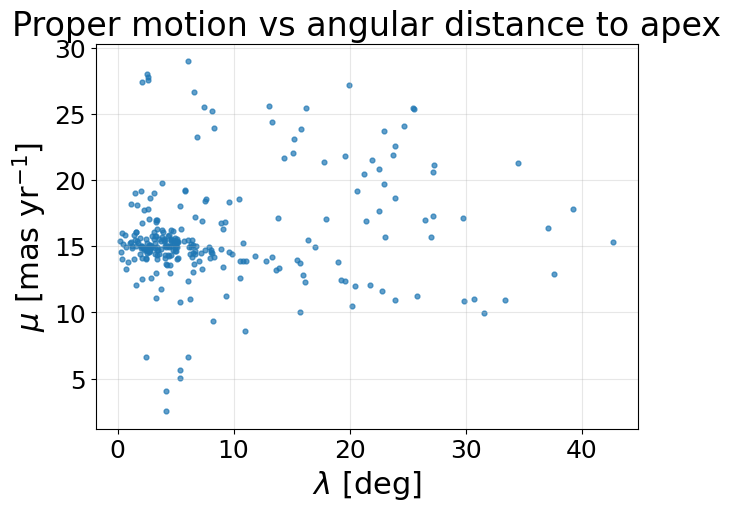

In [179]:
df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_f00.csv")
# df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_trace.csv")
# df = df[df['grupo']>0]
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc

nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df["cluster_id"] = (
    df["grupo"].astype(str) + "_" + df["numeracion"].astype(str)
)
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df["probabilidad"] = df["ConteoAgrupaciones"]/df["PresenteEnMuestras"]

df = df[df["cluster_id"]=="0_7"]

df = add_galactic_coordinates(df)
df = add_galactic_proper_motions(df)
df = add_initial_final_galactic_vectors(
    df,
    l_col="l",
    b_col="b",
    pm_l_col="pm_l_cosb",
    pm_b_col="pm_b",
    time_years=1.0,
    pm_l_is_cosb=True,
)
df = add_cross_product_poles(df)

# apex_result = estimate_apex_and_antapex(df)

# print("Apex:")
# print(apex_result["apex_l_deg"], apex_result["apex_b_deg"])

# print("Antapex:")
# print(apex_result["antapex_l_deg"], apex_result["antapex_b_deg"])

# print(
#     f"RMS residual: "
#     f"{apex_result['rms_pole_residual_deg']:.3f} deg"
# )

apex_result = estimate_apex_and_antapex(
    df,
    weight_col="probabilidad",
)

print(
    f"Apex: l={apex_result['apex_l_deg']:.3f} deg, "
    f"b={apex_result['apex_b_deg']:.3f} deg"
)

print(
    f"Antapex: l={apex_result['antapex_l_deg']:.3f} deg, "
    f"b={apex_result['antapex_b_deg']:.3f} deg"
)

print(
    f"RMS residual: "
    f"{apex_result['rms_pole_residual_deg']:.3f} deg"
)

df = add_lambda_angle_from_apex(
    df,
    apex_vector=apex_result["apex_vector"],
)
# df = add_lambda_angle_from_apex(
#     df,
#     apex_l_deg=apex_result["apex_l_deg"],
#     apex_b_deg=apex_result["apex_b_deg"],
# )
df["pm_total"] = np.sqrt(
    df["pm_l_cosb"] ** 2 + df["pm_b"] ** 2
)
df

plt.figure(figsize=(7, 5))

plt.scatter(
    df["lambda_deg"],
    df["pm_total"],
    s=12,
    alpha=0.7,
)

plt.xlabel(r"$\lambda$ [deg]")
plt.ylabel(r"$\mu$ [mas yr$^{-1}$]")
plt.title("Proper motion vs angular distance to apex")
plt.grid(alpha=0.3)
plt.show()

In [180]:
def process_cluster_apex(
    df_full: pd.DataFrame,
    cluster_id: object,
    cluster_col: str = "cluster_id",
    weight_col: Optional[str] = "probabilidad",
    min_stars: int = 5,
) -> Optional[Dict[str, object]]:
    """
    Process a single cluster to compute its apex, antapex, lambda
    angles, and proper-motion diagnostics.

    This function assumes that the input DataFrame has already been
    preprocessed with:
    - Galactic coordinates.
    - Galactic proper motions.
    - Initial/final unit vectors.
    - Pole vectors.

    Parameters
    ----------
    df_full : pd.DataFrame
        Full DataFrame containing all stars and clusters.
    cluster_id : object
        Cluster identifier to process.
    cluster_col : str, optional
        Name of the column containing cluster identifiers.
    weight_col : str or None, optional
        Column name used as weights for the apex estimation.
        If None, no weights are used.
    min_stars : int, optional
        Minimum number of stars required to process the cluster.

    Returns
    -------
    dict or None
        Dictionary containing:
        - cluster_id
        - n_stars
        - apex_result
        - df

        Returns None if the cluster cannot be processed.
    """

    required_columns = [
        cluster_col,
        "pm_l_cosb",
        "pm_b",
        "x_initial",
        "y_initial",
        "z_initial",
        "x_final",
        "y_final",
        "z_final",
        "pole_x_unit",
        "pole_y_unit",
        "pole_z_unit",
    ]

    if weight_col is not None:
        required_columns.append(weight_col)

    missing_columns = set(required_columns).difference(df_full.columns)
    if missing_columns:
        raise ValueError(
            "Missing required columns before processing cluster apex: "
            f"{', '.join(sorted(missing_columns))}"
        )

    df_cluster = df_full[df_full[cluster_col] == cluster_id].copy()

    if len(df_cluster) == 0:
        print(f"Cluster {cluster_id}: no data found.")
        return None

    if len(df_cluster) < min_stars:
        print(
            f"Cluster {cluster_id}: only {len(df_cluster)} stars. "
            f"Minimum required: {min_stars}."
        )
        return None

    effective_weight_col = weight_col

    if effective_weight_col is not None:
        valid_weights = (
            df_cluster[effective_weight_col].notna()
            & (df_cluster[effective_weight_col] > 0)
        )

        if valid_weights.sum() < min_stars:
            print(
                f"Cluster {cluster_id}: not enough valid weights. "
                "Apex will be estimated without weights."
            )
            effective_weight_col = None

    try:
        apex_result = estimate_apex_and_antapex(
            df_cluster,
            weight_col=effective_weight_col,
        )
    except ValueError as exc:
        print(f"Cluster {cluster_id}: error computing apex - {exc}")
        return None

    df_cluster = add_lambda_angle_from_apex(
        df_cluster,
        apex_vector=apex_result["apex_vector"],
    )

    df_cluster["pm_total"] = np.sqrt(
        df_cluster["pm_l_cosb"] ** 2 + df_cluster["pm_b"] ** 2
    )

    if "distance_pc" in df_cluster.columns:
        df_cluster["vt_kms"] = (
            4.74 * (df_cluster["pm_total"] / 1000.0)
            * df_cluster["distance_pc"]
        )

    return {
        "cluster_id": cluster_id,
        "n_stars": len(df_cluster),
        "apex_result": apex_result,
        "df": df_cluster,
    }

In [181]:
df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_f00.csv")

df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc

nueva_numeracion = np.arange(0, len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(), nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df["cluster_id"] = (
    df["grupo"].astype(str) + "_" + df["numeracion"].astype(str)
)
df["probabilidad"] = df["ConteoAgrupaciones"] / df["PresenteEnMuestras"]
df['cluster_id'].value_counts()

cluster_id
-1_0     68107
-1_15    47693
-1_2     27378
-1_8     25389
-1_17    24101
-1_4     24038
-1_7     23434
-1_14    20467
-1_5     14493
-1_13    13854
-1_9     13270
-1_12    12938
-1_6     12483
-1_16    12117
-1_11    12096
-1_3     11966
-1_1     11489
-1_10    10831
4_0        936
5_15       924
3_15       902
6_15       840
3_17       797
6_0        738
10_0       682
0_17       600
1_7        589
1_13       496
11_0       481
0_16       470
0_8        455
2_0        391
0_0        387
3_0        326
1_0        284
0_7        263
2_17       225
5_0        221
4_15       206
0_15       163
2_15       157
0_13       149
7_0        127
3_8        126
9_0        119
1_17       119
8_0        118
1_8         99
0_10        95
1_10        92
1_16        85
2_8         78
1_15        66
Name: count, dtype: int64

In [182]:
df[df["cluster_id"]=="7_0"].groupby("cluster_id").agg({"pmra":"mean","pmdec":"mean"})

,pmra,pmdec
cluster_id,,
7_0,-7.502505,3.723564


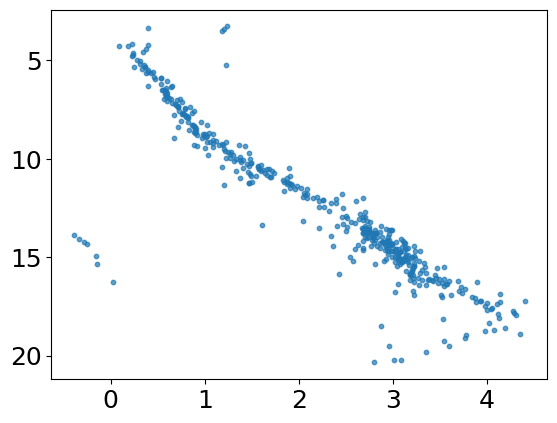

In [183]:
df_test = df[df['cluster_id']=='0_8']
plt.scatter(df_test['bp_rp'], df_test['phot_g_mean_mag'], s=10, alpha=0.7)
plt.gca().invert_yaxis()
# df_test

In [ ]:

# IMPORTANTE: Hacer el preprocessing EN EL DATAFRAME COMPLETO (sin filtrar por cluster)
print("Preprocessing del dataframe completo...")
df = add_galactic_coordinates(df)
df = add_galactic_proper_motions(df)
df = add_initial_final_galactic_vectors(
    df,
    l_col="l",
    b_col="b",
    pm_l_col="pm_l_cosb",
    pm_b_col="pm_b",
    time_years=1.0,
    pm_l_is_cosb=True,
)
df = add_cross_product_poles(df)

print(f"✓ Dataframe preparado con {len(df)} estrellas")

# Procesar múltiples clusters
clusters_to_process = ["0_8", "0_7"]  # Ajusta los números de clusters
clusters_results = {}

print("\n" + "=" * 70)
print("PROCESANDO MÚLTIPLES CLUSTERS")
print("=" * 70)

for cluster_id in clusters_to_process:
    result = process_cluster_apex(df, cluster_id, weight_col="probabilidad")
    
    if result is not None:
        clusters_results[cluster_id] = result
        
        apex = result["apex_result"]
        print(f"\n📍 CLUSTER {cluster_id} (N={result['n_stars']} estrellas)")
        print(f"   Apex:    l={apex['apex_l_deg']:.2f}°, b={apex['apex_b_deg']:.2f}°")
        print(f"   Antapex: l={apex['antapex_l_deg']:.2f}°, b={apex['antapex_b_deg']:.2f}°")
        print(f"   RMS residual: {apex['rms_pole_residual_deg']:.3f}°")
        print(f"   Movimiento hacia apex: {apex['toward_apex_fraction']*100:.1f}%")

print("\n" + "=" * 70)


Preprocessing del dataframe completo...
✓ Dataframe preparado con 398950 estrellas

PROCESANDO MÚLTIPLES CLUSTERS

📍 CLUSTER 0_8 (N=455 estrellas)
   Apex:    l=202.51°, b=-3.16°
   Antapex: l=22.51°, b=3.16°
   RMS residual: 1.058°
   Movimiento hacia apex: 100.0%

📍 CLUSTER 0_7 (N=263 estrellas)
   Apex:    l=243.43°, b=83.05°
   Antapex: l=63.43°, b=-83.05°
   RMS residual: 5.536°
   Movimiento hacia apex: 71.1%



In [190]:
pairwise_result = estimate_apex_from_pairwise_pole_crosses(
    df[df["cluster_id"] == "0_8"] ,
    pole_x_col="pole_x_unit",
    pole_y_col="pole_y_unit",
    pole_z_col="pole_z_unit",
    x_initial_col="x_initial",
    y_initial_col="y_initial",
    z_initial_col="z_initial",
    x_final_col="x_final",
    y_final_col="y_final",
    z_final_col="z_final",
    weight_col=None,
    orient_with_motion=True,
    max_pairs=None,
)

print("Apex l, b:")
print(pairwise_result["apex_l_deg"], pairwise_result["apex_b_deg"])

print("Antapex l, b:")
print(pairwise_result["antapex_l_deg"], pairwise_result["antapex_b_deg"])

print("RMS pares apex:", pairwise_result["rms_pair_apex_residual_deg"])
print("RMS polos:", pairwise_result["rms_pole_residual_deg"])

Apex l, b:
202.226841079822 -3.512717481994209
Antapex l, b:
22.226841079822037 3.512717481994209
RMS pares apex: 26.226050036859096
RMS polos: 1.5000619427500723


In [189]:
pairwise_result = estimate_apex_from_pairwise_pole_crosses(
    df[df["cluster_id"] == "0_7"],
    pole_x_col="pole_x_unit",
    pole_y_col="pole_y_unit",
    pole_z_col="pole_z_unit",
    x_initial_col="x_initial",
    y_initial_col="y_initial",
    z_initial_col="z_initial",
    x_final_col="x_final",
    y_final_col="y_final",
    z_final_col="z_final",
    weight_col=None,
    orient_with_motion=True,
    max_pairs=None,
)

print("Apex l, b:")
print(pairwise_result["apex_l_deg"], pairwise_result["apex_b_deg"])

print("Antapex l, b:")
print(pairwise_result["antapex_l_deg"], pairwise_result["antapex_b_deg"])

print("RMS pares apex:", pairwise_result["rms_pair_apex_residual_deg"])
print("RMS polos:", pairwise_result["rms_pole_residual_deg"])

Apex l, b:
85.26676639081981 -86.7100323736473
Antapex l, b:
265.26676639081984 86.7100323736473
RMS pares apex: 50.798929302707656
RMS polos: 9.598024262592578


In [185]:
# df_test.to_csv("coma_sample.csv")

(-28.889723369524326,
 1.9983099106636797,
 -21.449944135373972,
 2.9280446708017864)

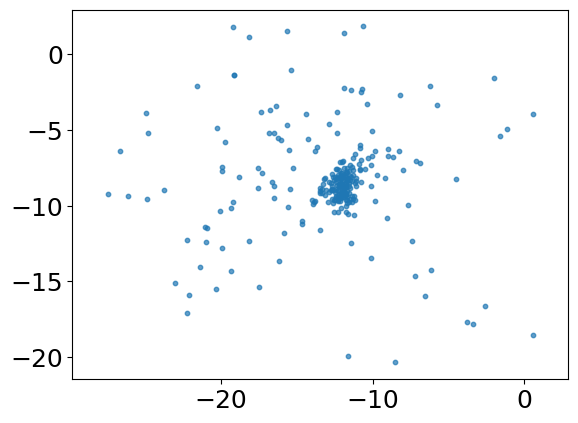

In [186]:
adf_test = df[df["cluster_id"]=="0_7"]
plt.scatter(adf_test["pmra"], adf_test["pmdec"], s=10, alpha=0.7)
plt.axis("equal")

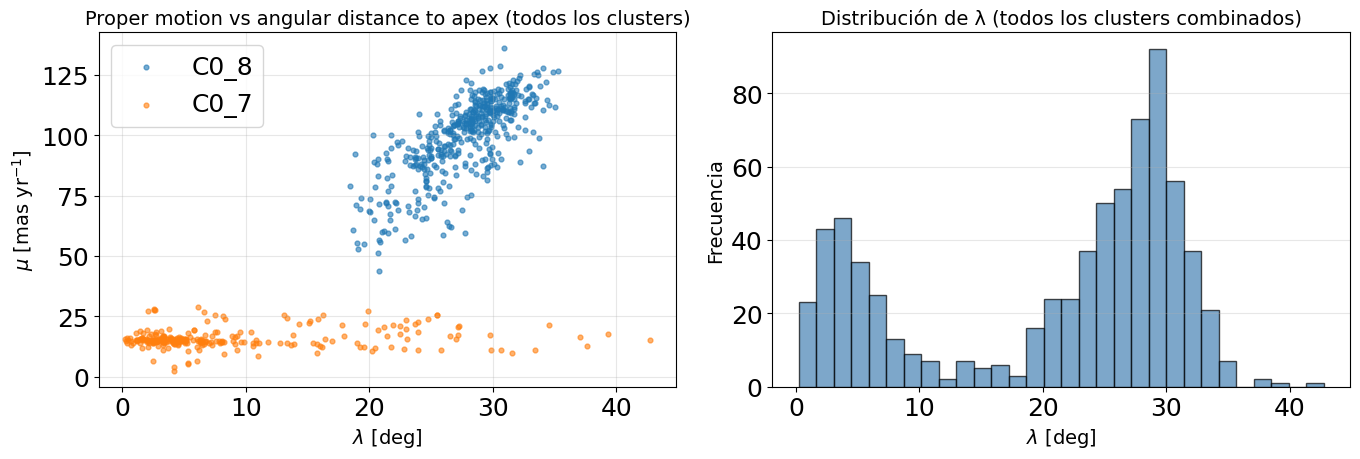


TABLA RESUMEN DE APEX POR CLUSTER
Cluster  N_estrellas Apex_L (deg) Apex_B (deg) RMS_residual (deg) Hacia_apex (%)
    0_8          455       202.51        -3.16              1.058          100.0
    0_7          263       243.43        83.05              5.536           71.1


In [187]:
# Visualización: Movimiento propio vs lambda para TODOS los clusters combinados
# Combinar datos de todos los clusters procesados

all_data = []
for cluster_id, result in clusters_results.items():
    df_cluster = result["df"].copy()
    df_cluster["cluster_label"] = f"C{cluster_id}"
    all_data.append(df_cluster)

df_combined = pd.concat(all_data, ignore_index=True)

# Gráfica con colores por cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Scatter plot
ax = axes[0]
for cluster_id, result in clusters_results.items():
    df_cluster = result["df"]
    ax.scatter(
        df_cluster["lambda_deg"],
        df_cluster["pm_total"],
        s=12,
        alpha=0.6,
        label=f"C{cluster_id}"
    )

ax.set_xlabel(r"$\lambda$ [deg]", fontsize=14)
ax.set_ylabel(r"$\mu$ [mas yr$^{-1}$]", fontsize=14)
ax.set_title("Proper motion vs angular distance to apex (todos los clusters)", fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Gráfica 2: Histograma de lambda para todos
ax = axes[1]
ax.hist(df_combined["lambda_deg"], bins=30, alpha=0.7, color="steelblue", edgecolor="black")
ax.set_xlabel(r"$\lambda$ [deg]", fontsize=14)
ax.set_ylabel("Frecuencia", fontsize=14)
ax.set_title("Distribución de λ (todos los clusters combinados)", fontsize=14)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabla resumen de apex
print("\n" + "=" * 90)
print("TABLA RESUMEN DE APEX POR CLUSTER")
print("=" * 90)

summary_data = []
for cluster_id, result in clusters_results.items():
    apex = result["apex_result"]
    summary_data.append({
        "Cluster": cluster_id,
        "N_estrellas": result["n_stars"],
        "Apex_L (deg)": f"{apex['apex_l_deg']:.2f}",
        "Apex_B (deg)": f"{apex['apex_b_deg']:.2f}",
        "RMS_residual (deg)": f"{apex['rms_pole_residual_deg']:.3f}",
        "Hacia_apex (%)": f"{apex['toward_apex_fraction']*100:.1f}",
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print("=" * 90)


In [153]:
df.columns

Index(['Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'ruwe', 'phot_g_mean_mag', 'bp_rp', 'radial_velocity', 'ra_error',
       'dec_error', 'pmra_error', 'pmdec_error', 'parallax_error',
       'visibility_periods_used', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
       'nu_eff_used_in_astrometry', 'pseudocolour', 'ecl_lat',
       'astrometric_params_solved', 'zp', 'parallax_corrected', 'fidelity_v2',
       'fidelity_v1', 'wx', 'wy', 'wz', 'pmra_corrected', 'pmdec_corrected',
       'ra_relative_error', 'dec_relative_error', 'pmra_relative_error',
       'pmdec_relative_error', 'parallax_relative_error', 'indice_original',
       'pmra_corrected_norm', 'pmdec_corrected_norm',
       'parallax_corrected_norm', 'ra_norm', 'dec_norm', 'source_id.1',
       'MediaProbabilidad', 'ConteoAgrupaciones', 'PresenteEnMuestras',
       'iteraciones', 'grupo', 'coordenada_ra', 'coordenada_dec', 'division',
       'distance_pc', 'numeracion', 'cluster_id', 'probabilidad'

In [154]:
# Ejemplos de cómo acceder a datos individuales de cada cluster

print("EJEMPLOS DE ACCESO A DATOS DE CLUSTERS INDIVIDUALES")
print("=" * 70)

# Acceder a los datos de un cluster específico
cluster_results = ["0_8","7_0","0,7"]
if cluster_id in clusters_results:
    result = clusters_results[cluster_id]
    df_cluster = result["df"]
    apex_info = result["apex_result"]
    
    print(f"\n1. Datos del cluster {cluster_id}:")
    print(f"   - Número de estrellas: {result['n_stars']}")
    print(f"   - Apex: ({apex_info['apex_l_deg']:.2f}, {apex_info['apex_b_deg']:.2f})")
    print(f"   - Primeras 5 filas con lambda y pm_total:")
    print(df_cluster[["ra", "dec", "lambda_deg", "pm_total"]].head())
    
    # Acceder a datos del apex vector
    print(f"\n2. Vector apex del cluster {cluster_id}:")
    print(f"   {apex_info['apex_vector']}")
    
    # Filtrar estrellas por criterios
    print(f"\n3. Filtros de ejemplo:")
    stars_moving_apex = df_cluster[df_cluster["lambda_deg"] < 30]
    print(f"   - Estrellas con λ < 30°: {len(stars_moving_apex)}")
    
    high_pm = df_cluster[df_cluster["pm_total"] > 10]
    print(f"   - Estrellas con μ > 10 mas/yr: {len(high_pm)}")

# Construir tabla con métricas de cada cluster
print("\n" + "=" * 70)
print("ESTADÍSTICAS DE MOVIMIENTO PROPIO POR CLUSTER")
print("=" * 70)

stats_data = []
for cluster_id, result in clusters_results.items():
    df_cluster = result["df"]
    stats_data.append({
        "Cluster": cluster_id,
        "μ_media (mas/yr)": f"{df_cluster['pm_total'].mean():.2f}",
        "μ_std (mas/yr)": f"{df_cluster['pm_total'].std():.2f}",
        "λ_media (deg)": f"{df_cluster['lambda_deg'].mean():.2f}",
        "λ_std (deg)": f"{df_cluster['lambda_deg'].std():.2f}",
    })

df_stats = pd.DataFrame(stats_data)
print(df_stats.to_string(index=False))
print("=" * 70)


EJEMPLOS DE ACCESO A DATOS DE CLUSTERS INDIVIDUALES

1. Datos del cluster 0_7:
   - Número de estrellas: 263
   - Apex: (243.43, 83.05)
   - Primeras 5 filas con lambda y pm_total:
                ra        dec  lambda_deg   pm_total
175081  203.382433  26.591813   15.747562  13.703483
175468  211.653082  20.054249   23.726005  21.939388
175541  210.112302  23.606213   21.773428  12.110961
175858  201.413986  25.682149   13.883451  13.372405
175897  200.545663  26.880868   13.299413  14.159070

2. Vector apex del cluster 0_7:
   [-0.05409827 -0.10815772  0.99266071]

3. Filtros de ejemplo:
   - Estrellas con λ < 30°: 255
   - Estrellas con μ > 10 mas/yr: 254

ESTADÍSTICAS DE MOVIMIENTO PROPIO POR CLUSTER
Cluster μ_media (mas/yr) μ_std (mas/yr) λ_media (deg) λ_std (deg)
    8_0            10.51           1.78        174.72        1.82
    0_7            15.81           3.94          8.70        8.57


In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Utilidades estadísticas
# ============================================================

def weighted_mean(values, weights=None):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    if weights is None:
        return np.mean(values[valid])

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0

    return np.average(values[valid], weights=weights[valid])


def weighted_std(values, weights=None):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    if weights is None:
        return np.std(values[valid], ddof=1)

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0

    x = values[valid]
    w = weights[valid]
    mean = np.average(x, weights=w)

    return np.sqrt(np.average((x - mean) ** 2, weights=w))


def weighted_rms(values, weights=None):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    if weights is None:
        return np.sqrt(np.mean(values[valid] ** 2))

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0

    return np.sqrt(np.average(values[valid] ** 2, weights=weights[valid]))


def weighted_quantile(values, quantiles, weights=None):
    """
    Calcula cuantiles ponderados.

    quantiles debe estar entre 0 y 1.
    Por ejemplo:

        quantiles = [0.16, 0.50, 0.84]
    """
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    valid = np.isfinite(values)

    if weights is None:
        return np.quantile(values[valid], quantiles)

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0

    x = values[valid]
    w = weights[valid]

    sorter = np.argsort(x)
    x = x[sorter]
    w = w[sorter]

    cumulative_weight = np.cumsum(w)
    cumulative_weight = cumulative_weight / cumulative_weight[-1]

    return np.interp(quantiles, cumulative_weight, x)


def robust_sigma_mad(values):
    """
    Sigma robusto usando MAD:

        sigma_robusto = 1.4826 * median(|x - median(x)|)

    Es menos sensible a outliers que la desviación estándar común.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    median = np.median(values)
    mad = np.median(np.abs(values - median))

    return 1.4826 * mad


def summarize_distribution(values_deg, weights=None, name="values"):
    """
    Resume una distribución angular en grados.
    """
    values_deg = np.asarray(values_deg, dtype=float)
    valid = np.isfinite(values_deg)

    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        valid &= np.isfinite(weights)
        valid &= weights > 0
        weights_valid = weights[valid]
    else:
        weights_valid = None

    x = values_deg[valid]

    q16, q50, q84 = weighted_quantile(
        x,
        [0.16, 0.50, 0.84],
        weights=weights_valid,
    )

    summary = {
        "name": name,
        "n": int(len(x)),
        "mean_deg": weighted_mean(x, weights_valid),
        "median_deg": q50,
        "std_deg": weighted_std(x, weights_valid),
        "rms_deg": weighted_rms(x, weights_valid),
        "robust_sigma_mad_deg": robust_sigma_mad(x),
        "q16_deg": q16,
        "q84_deg": q84,
        "p68_half_width_deg": 0.5 * (q84 - q16),
        "min_deg": np.min(x),
        "max_deg": np.max(x),
    }

    return summary


def print_summary(summary):
    """
    Imprime un resumen estadístico de forma legible.
    """
    print(f"\n=== {summary['name']} ===")
    print(f"n                         : {summary['n']}")
    print(f"mean [deg]                : {summary['mean_deg']:.6f}")
    print(f"median [deg]              : {summary['median_deg']:.6f}")
    print(f"std [deg]                 : {summary['std_deg']:.6f}")
    print(f"RMS [deg]                 : {summary['rms_deg']:.6f}")
    print(f"robust sigma MAD [deg]    : {summary['robust_sigma_mad_deg']:.6f}")
    print(f"q16 [deg]                 : {summary['q16_deg']:.6f}")
    print(f"q84 [deg]                 : {summary['q84_deg']:.6f}")
    print(f"68% half-width [deg]      : {summary['p68_half_width_deg']:.6f}")
    print(f"min [deg]                 : {summary['min_deg']:.6f}")
    print(f"max [deg]                 : {summary['max_deg']:.6f}")


# ============================================================
# 2. Utilidades vectoriales
# ============================================================

def normalize_vectors(vectors):
    """
    Normaliza un array de vectores fila por fila.

    Entrada:
        vectors.shape == (n, 3)

    Salida:
        unit_vectors.shape == (n, 3)
        norms.shape == (n,)
    """
    vectors = np.asarray(vectors, dtype=float)
    norms = np.linalg.norm(vectors, axis=1)

    valid = np.isfinite(vectors).all(axis=1)
    valid &= norms > 0

    unit_vectors = np.full_like(vectors, np.nan)
    unit_vectors[valid] = vectors[valid] / norms[valid, None]

    return unit_vectors, norms, valid


def angular_distance_between_vectors_deg(vector_a, vector_b, axial=False):
    """
    Calcula la distancia angular entre dos vectores 3D.

    Si axial=True, trata A y -A como la misma dirección.
    Esto sirve para comparar ejes apex-antapex.
    """
    a = np.asarray(vector_a, dtype=float)
    b = np.asarray(vector_b, dtype=float)

    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)

    dot = np.dot(a, b)

    if axial:
        dot = np.abs(dot)

    dot = np.clip(dot, -1.0, 1.0)

    return np.degrees(np.arccos(dot))


# ============================================================
# 3. Agregar diagnósticos por estrella al DataFrame
# ============================================================

def add_apex_diagnostics_to_df(
    df: pd.DataFrame,
    apex_result: dict,
    prefix: str = "apex",
    x_col: str = "x_initial",
    y_col: str = "y_initial",
    z_col: str = "z_initial",
    pole_x_col: str = "pole_x_unit",
    pole_y_col: str = "pole_y_unit",
    pole_z_col: str = "pole_z_unit",
    weight_col: str | None = None,
    copy: bool = True,
) -> pd.DataFrame:
    """
    Agrega diagnósticos por estrella respecto a un apex estimado.

    Agrega columnas como:

        prefix_lambda_deg
        prefix_lambda_rad
        prefix_cos_lambda
        prefix_sin_lambda
        prefix_pole_residual_deg
        prefix_pole_residual_rad
        prefix_pole_residual_sigma
        prefix_lambda_sigma

    Interpretación
    --------------
    lambda mide separación angular estrella-apex:

        cos(lambda) = r_star dot apex

    pole_residual mide qué tan perpendicular es el polo al apex:

        residual = arcsin(|pole dot apex|)

    Si el modelo es bueno, pole_residual debería concentrarse cerca de 0.
    """

    required_columns = [
        x_col,
        y_col,
        z_col,
        pole_x_col,
        pole_y_col,
        pole_z_col,
    ]

    if weight_col is not None:
        required_columns.append(weight_col)

    validate_columns(df, required_columns)

    result = df.copy() if copy else df

    apex_vector = np.asarray(apex_result["apex_vector"], dtype=float)
    apex_vector = apex_vector / np.linalg.norm(apex_vector)

    star_vectors = result[[x_col, y_col, z_col]].to_numpy(dtype=float)
    pole_vectors = result[[pole_x_col, pole_y_col, pole_z_col]].to_numpy(dtype=float)

    star_unit_vectors, star_norms, valid_star = normalize_vectors(star_vectors)
    pole_unit_vectors, pole_norms, valid_pole = normalize_vectors(pole_vectors)

    valid = valid_star & valid_pole

    cos_lambda = np.full(len(result), np.nan)
    lambda_rad = np.full(len(result), np.nan)

    pole_plane_residual = np.full(len(result), np.nan)
    pole_residual_rad = np.full(len(result), np.nan)

    # Ángulo lambda estrella-apex.
    cos_lambda[valid] = star_unit_vectors[valid] @ apex_vector
    cos_lambda = np.clip(cos_lambda, -1.0, 1.0)

    lambda_rad[valid] = np.arccos(cos_lambda[valid])

    # Residual del polo respecto al apex.
    # Idealmente pole dot apex = 0.
    pole_plane_residual[valid] = np.abs(pole_unit_vectors[valid] @ apex_vector)
    pole_plane_residual = np.clip(pole_plane_residual, 0.0, 1.0)

    pole_residual_rad[valid] = np.arcsin(pole_plane_residual[valid])

    result[f"{prefix}_lambda_rad"] = lambda_rad
    result[f"{prefix}_lambda_deg"] = np.degrees(lambda_rad)
    result[f"{prefix}_cos_lambda"] = cos_lambda
    result[f"{prefix}_sin_lambda"] = np.sin(lambda_rad)

    result[f"{prefix}_pole_residual_rad"] = pole_residual_rad
    result[f"{prefix}_pole_residual_deg"] = np.degrees(pole_residual_rad)

    result[f"{prefix}_valid_apex_diagnostic"] = valid

    # Pesos, si existen.
    if weight_col is not None:
        weights = result[weight_col].to_numpy(dtype=float)
    else:
        weights = None

    # Sigma para residuales de polos.
    pole_residual_deg = result[f"{prefix}_pole_residual_deg"].to_numpy(dtype=float)

    pole_mean = weighted_mean(pole_residual_deg, weights)
    pole_sigma = weighted_std(pole_residual_deg, weights)

    result[f"{prefix}_pole_residual_centered_deg"] = pole_residual_deg - pole_mean

    if pole_sigma > 0:
        result[f"{prefix}_pole_residual_sigma"] = (
            result[f"{prefix}_pole_residual_centered_deg"] / pole_sigma
        )
    else:
        result[f"{prefix}_pole_residual_sigma"] = np.nan

    # Sigma para lambda.
    lambda_deg = result[f"{prefix}_lambda_deg"].to_numpy(dtype=float)

    lambda_mean = weighted_mean(lambda_deg, weights)
    lambda_sigma = weighted_std(lambda_deg, weights)

    result[f"{prefix}_lambda_centered_deg"] = lambda_deg - lambda_mean

    if lambda_sigma > 0:
        result[f"{prefix}_lambda_sigma"] = (
            result[f"{prefix}_lambda_centered_deg"] / lambda_sigma
        )
    else:
        result[f"{prefix}_lambda_sigma"] = np.nan

    return result


# ============================================================
# 4. Gráficas básicas
# ============================================================

def plot_histogram_with_stats(
    values_deg,
    title: str,
    xlabel: str,
    weights=None,
    bins: int = 50,
):
    """
    Histograma con líneas de media, mediana, RMS y bandas de 1 sigma.
    """
    values_deg = np.asarray(values_deg, dtype=float)
    valid = np.isfinite(values_deg)

    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        valid &= np.isfinite(weights)
        valid &= weights > 0
        weights_plot = weights[valid]
    else:
        weights_plot = None

    x = values_deg[valid]

    mean = weighted_mean(x, weights_plot)
    median = weighted_quantile(x, [0.50], weights_plot)[0]
    sigma = weighted_std(x, weights_plot)
    rms = weighted_rms(x, weights_plot)

    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=bins, weights=weights_plot, alpha=0.8)
    plt.axvline(mean, linestyle="--", label=f"media = {mean:.3f}°")
    plt.axvline(median, linestyle="-", label=f"mediana = {median:.3f}°")
    plt.axvline(rms, linestyle=":", label=f"RMS = {rms:.3f}°")

    plt.axvline(mean - sigma, linestyle="--", label=f"-1σ = {mean - sigma:.3f}°")
    plt.axvline(mean + sigma, linestyle="--", label=f"+1σ = {mean + sigma:.3f}°")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia ponderada" if weights_plot is not None else "Frecuencia")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_cumulative_distribution(
    values_deg,
    title: str,
    xlabel: str,
    weights=None,
):
    """
    Distribución acumulada.

    Sirve para ver percentiles y colas.
    """
    values_deg = np.asarray(values_deg, dtype=float)
    valid = np.isfinite(values_deg)

    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        valid &= np.isfinite(weights)
        valid &= weights > 0

        x = values_deg[valid]
        w = weights[valid]

        sorter = np.argsort(x)
        x = x[sorter]
        w = w[sorter]

        y = np.cumsum(w)
        y = y / y[-1]

    else:
        x = np.sort(values_deg[valid])
        y = np.arange(1, len(x) + 1) / len(x)

    plt.figure(figsize=(8, 5))
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Fracción acumulada")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_sigma_distribution(
    sigma_values,
    title: str,
    bins: int = 50,
):
    """
    Histograma de valores en unidades de sigma.
    """
    sigma_values = np.asarray(sigma_values, dtype=float)
    sigma_values = sigma_values[np.isfinite(sigma_values)]

    plt.figure(figsize=(8, 5))
    plt.hist(sigma_values, bins=bins, alpha=0.8)
    plt.axvline(-3, linestyle="--", label="-3σ")
    plt.axvline(-2, linestyle="--", label="-2σ")
    plt.axvline(-1, linestyle="--", label="-1σ")
    plt.axvline(0, linestyle="-", label="0σ")
    plt.axvline(1, linestyle="--", label="+1σ")
    plt.axvline(2, linestyle="--", label="+2σ")
    plt.axvline(3, linestyle="--", label="+3σ")
    plt.title(title)
    plt.xlabel("Valor en unidades de sigma")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_residual_vs_lambda(
    df: pd.DataFrame,
    prefix: str,
):
    """
    Gráfica de residual del polo contra lambda.
    """
    lambda_col = f"{prefix}_lambda_deg"
    residual_col = f"{prefix}_pole_residual_deg"

    validate_columns(df, [lambda_col, residual_col])

    x = df[lambda_col].to_numpy(dtype=float)
    y = df[residual_col].to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    plt.figure(figsize=(8, 5))
    plt.scatter(x[valid], y[valid], s=10, alpha=0.6)
    plt.title(f"Residual del polo vs lambda — {prefix}")
    plt.xlabel("lambda [deg]")
    plt.ylabel("Residual del polo [deg]")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_sky_residual_map(
    df: pd.DataFrame,
    prefix: str,
    l_col: str = "l",
    b_col: str = "b",
):
    """
    Mapa simple l-b coloreado por residual.

    Requiere que el DataFrame tenga columnas l y b en grados.
    """
    residual_col = f"{prefix}_pole_residual_deg"

    validate_columns(df, [l_col, b_col, residual_col])

    l = df[l_col].to_numpy(dtype=float)
    b = df[b_col].to_numpy(dtype=float)
    residual = df[residual_col].to_numpy(dtype=float)

    valid = np.isfinite(l) & np.isfinite(b) & np.isfinite(residual)

    plt.figure(figsize=(9, 5))
    scatter = plt.scatter(
        l[valid],
        b[valid],
        c=residual[valid],
        s=10,
        alpha=0.7,
    )
    plt.colorbar(scatter, label="Residual del polo [deg]")
    plt.title(f"Mapa galáctico de residuales — {prefix}")
    plt.xlabel("l [deg]")
    plt.ylabel("b [deg]")
    plt.grid(True, alpha=0.3)
    plt.show()


# ============================================================
# 5. Función principal de gráficas por resultado
# ============================================================

def plot_apex_diagnostics(
    df: pd.DataFrame,
    prefix: str = "apex",
    weight_col: str | None = None,
    bins: int = 50,
    make_sky_map: bool = True,
):
    """
    Genera varias gráficas diagnósticas para un apex ya agregado al df
    con add_apex_diagnostics_to_df.
    """

    lambda_col = f"{prefix}_lambda_deg"
    residual_col = f"{prefix}_pole_residual_deg"
    residual_sigma_col = f"{prefix}_pole_residual_sigma"
    lambda_sigma_col = f"{prefix}_lambda_sigma"

    validate_columns(
        df,
        [
            lambda_col,
            residual_col,
            residual_sigma_col,
            lambda_sigma_col,
        ],
    )

    if weight_col is not None:
        validate_columns(df, [weight_col])
        weights = df[weight_col].to_numpy(dtype=float)
    else:
        weights = None

    lambda_deg = df[lambda_col].to_numpy(dtype=float)
    residual_deg = df[residual_col].to_numpy(dtype=float)
    residual_sigma = df[residual_sigma_col].to_numpy(dtype=float)
    lambda_sigma = df[lambda_sigma_col].to_numpy(dtype=float)

    # Resúmenes numéricos.
    lambda_summary = summarize_distribution(
        lambda_deg,
        weights=weights,
        name=f"{prefix}: lambda estrella-apex",
    )

    residual_summary = summarize_distribution(
        residual_deg,
        weights=weights,
        name=f"{prefix}: residual polo-apex",
    )

    print_summary(lambda_summary)
    print_summary(residual_summary)

    # Histograma de lambda.
    plot_histogram_with_stats(
        lambda_deg,
        title=f"Distribución de lambda — {prefix}",
        xlabel="lambda [deg]",
        weights=weights,
        bins=bins,
    )

    # Histograma del residual.
    plot_histogram_with_stats(
        residual_deg,
        title=f"Distribución del residual polo-apex — {prefix}",
        xlabel="Residual del polo [deg]",
        weights=weights,
        bins=bins,
    )

    # Acumulada del residual.
    plot_cumulative_distribution(
        residual_deg,
        title=f"Distribución acumulada del residual — {prefix}",
        xlabel="Residual del polo [deg]",
        weights=weights,
    )

    # Sigma del residual.
    plot_sigma_distribution(
        residual_sigma,
        title=f"Residual del polo en unidades de sigma — {prefix}",
        bins=bins,
    )

    # Sigma de lambda.
    plot_sigma_distribution(
        lambda_sigma,
        title=f"Lambda en unidades de sigma — {prefix}",
        bins=bins,
    )

    # Residual vs lambda.
    plot_residual_vs_lambda(df, prefix=prefix)

    # Mapa galáctico, si existen columnas l y b.
    if make_sky_map and ("l" in df.columns) and ("b" in df.columns):
        plot_sky_residual_map(df, prefix=prefix, l_col="l", b_col="b")


# ============================================================
# 6. Diagnósticos para el método pairwise
# ============================================================

def plot_pairwise_candidate_diagnostics(
    pairwise_result: dict,
    bins: int = 50,
):
    """
    Grafica la distribución de residuales de los apex candidatos generados
    por productos cruzados entre pares de polos.

    Para que esto funcione, debes haber llamado:

        estimate_apex_from_pairwise_pole_crosses(..., return_pair_details=True)
    """

    if "pair_apex_residual_deg" not in pairwise_result:
        raise ValueError(
            "pairwise_result does not contain pair_apex_residual_deg. "
            "Run estimate_apex_from_pairwise_pole_crosses with "
            "return_pair_details=True."
        )

    pair_residual = np.asarray(
        pairwise_result["pair_apex_residual_deg"],
        dtype=float,
    )

    pair_weights = pairwise_result.get("pair_weights", None)

    if pair_weights is not None:
        pair_weights = np.asarray(pair_weights, dtype=float)

    summary = summarize_distribution(
        pair_residual,
        weights=pair_weights,
        name="Pairwise: residual candidatos apex",
    )

    print_summary(summary)

    plot_histogram_with_stats(
        pair_residual,
        title="Distribución de residuales de candidatos pairwise",
        xlabel="Distancia angular candidato-apex final [deg]",
        weights=pair_weights,
        bins=bins,
    )

    plot_cumulative_distribution(
        pair_residual,
        title="Distribución acumulada de residuales pairwise",
        xlabel="Distancia angular candidato-apex final [deg]",
        weights=pair_weights,
    )


# ============================================================
# 7. Comparar dos resultados de apex
# ============================================================

def compare_two_apex_results(
    result_a: dict,
    result_b: dict,
    name_a: str = "original",
    name_b: str = "pairwise",
):
    """
    Compara dos apex estimados.
    """

    apex_a = np.asarray(result_a["apex_vector"], dtype=float)
    apex_b = np.asarray(result_b["apex_vector"], dtype=float)

    # Comparación direccional:
    # distingue apex de antapex.
    direct_angle = angular_distance_between_vectors_deg(
        apex_a,
        apex_b,
        axial=False,
    )

    # Comparación axial:
    # trata apex y antapex como el mismo eje.
    axial_angle = angular_distance_between_vectors_deg(
        apex_a,
        apex_b,
        axial=True,
    )

    print("\n=== Comparación de apex ===")
    print(f"{name_a} apex l,b [deg] : {result_a['apex_l_deg']:.6f}, {result_a['apex_b_deg']:.6f}")
    print(f"{name_b} apex l,b [deg] : {result_b['apex_l_deg']:.6f}, {result_b['apex_b_deg']:.6f}")
    print(f"Diferencia direccional [deg] : {direct_angle:.6f}")
    print(f"Diferencia axial [deg]       : {axial_angle:.6f}")

    keys_to_compare = [
        "rms_pole_residual_deg",
        "median_pole_residual_deg",
        "toward_apex_fraction",
    ]

    print("\nMétricas comparables:")
    for key in keys_to_compare:
        if key in result_a and key in result_b:
            print(f"{key}")
            print(f"  {name_a}: {result_a[key]}")
            print(f"  {name_b}: {result_b[key]}")

In [ ]:
df_compare = df[df["cluster_id"] == "0_8"]
original_result = estimate_apex_and_antapex(
    df_compare,
    weight_col=None,
    orient_with_motion=True,
)

pairwise_result = estimate_apex_from_pairwise_pole_crosses(
    df_compare,
    weight_col=None,
    orient_with_motion=True,
    max_pairs=None,
    return_pair_details=True,
)

df_diag = add_apex_diagnostics_to_df(
    df_compare,
    original_result,
    prefix="original",
    weight_col=None,
)

df_diag


In [197]:
df_diag = add_apex_diagnostics_to_df(
    df_compare,
    original_result,
    prefix="original",
    weight_col=None,
)
df_diag

,Unnamed: 0,source_id,ra,dec,parallax,pmra,pmdec,ruwe,phot_g_mean_mag,bp_rp,...,original_lambda_deg,original_cos_lambda,original_sin_lambda,original_pole_residual_rad,original_pole_residual_deg,original_valid_apex_diagnostic,original_pole_residual_centered_deg,original_pole_residual_sigma,original_lambda_centered_deg,original_lambda_sigma
210164,1628264,45198178534988672,62.490400,15.416884,21.226790,118.522696,-21.854283,1.516279,14.580980,3.142399,...,32.092258,0.847194,0.531284,0.008091,0.463602,True,-0.439109,-0.366478,5.255465,1.495071
210165,1628267,45293526808851200,62.865737,15.992065,20.975848,117.535943,-19.692321,1.130458,13.776278,2.822394,...,31.837716,0.849546,0.527515,0.010812,0.619481,True,-0.283230,-0.236382,5.000922,1.422659
210169,1628297,45845378567048320,64.006596,16.982964,21.622122,117.389516,-29.940662,1.218000,13.754810,2.825718,...,30.969875,0.857438,0.514587,0.012061,0.691071,True,-0.211639,-0.176633,4.133081,1.175776
210192,1629424,47620265212420096,64.508186,18.256666,21.569793,113.307985,-31.327170,1.935553,7.371560,0.841778,...,30.818145,0.858798,0.512315,0.000697,0.039928,True,-0.862782,-0.720073,3.981351,1.132612
210195,1629644,48455894049191424,63.624805,18.729881,20.680377,110.101280,-30.568058,3.769246,13.204377,2.762054,...,31.751617,0.850337,0.526238,0.000329,0.018866,True,-0.883845,-0.737652,4.914824,1.398166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224516,2195024,3411811317161811328,72.569882,20.625627,22.051541,89.481733,-44.390825,1.256963,13.134485,2.683378,...,24.584863,0.909346,0.416041,0.008703,0.498642,True,-0.404068,-0.337233,-2.251930,-0.640628
224529,2196160,3409548556593300480,69.937873,18.094693,22.314480,102.884844,-34.193192,1.081794,16.200205,3.600326,...,25.848678,0.899949,0.435996,0.009771,0.559851,True,-0.342859,-0.286149,-0.988116,-0.281099
224531,2196198,3410559832411244160,69.965462,19.659390,23.499067,87.291986,-34.152279,16.270372,14.677451,3.234291,...,26.389627,0.895792,0.444473,0.010124,0.580055,True,-0.322655,-0.269286,-0.447167,-0.127210
224561,2197417,3411727788638518144,73.723012,20.869290,14.729442,58.183558,-30.415602,1.011372,16.923727,3.515862,...,23.754655,0.915279,0.402821,0.014208,0.814045,True,-0.088666,-0.074000,-3.082138,-0.876805


In [199]:
df_diag = add_apex_diagnostics_to_df(
    df_diag,
    pairwise_result,
    prefix="pairwise",
    weight_col=None,
)
df_diag

,Unnamed: 0,source_id,ra,dec,parallax,pmra,pmdec,ruwe,phot_g_mean_mag,bp_rp,...,pairwise_lambda_deg,pairwise_cos_lambda,pairwise_sin_lambda,pairwise_pole_residual_rad,pairwise_pole_residual_deg,pairwise_valid_apex_diagnostic,pairwise_pole_residual_centered_deg,pairwise_pole_residual_sigma,pairwise_lambda_centered_deg,pairwise_lambda_sigma
210164,1628264,45198178534988672,62.490400,15.416884,21.226790,118.522696,-21.854283,1.516279,14.580980,3.142399,...,32.476716,0.843610,0.536957,0.007026,0.402543,True,-0.492010,-0.408149,5.253988,1.494478
210165,1628267,45293526808851200,62.865737,15.992065,20.975848,117.535943,-19.692321,1.130458,13.776278,2.822394,...,32.223448,0.845975,0.533223,0.011941,0.684192,True,-0.210362,-0.174506,5.000720,1.422437
210169,1628297,45845378567048320,64.006596,16.982964,21.622122,117.389516,-29.940662,1.218000,13.754810,2.825718,...,31.357598,0.853936,0.520378,0.011455,0.656305,True,-0.238248,-0.197640,4.134870,1.176149
210192,1629424,47620265212420096,64.508186,18.256666,21.569793,113.307985,-31.327170,1.935553,7.371560,0.841778,...,31.207397,0.855297,0.518137,0.000274,0.015688,True,-0.878865,-0.729066,3.984669,1.133425
210195,1629644,48455894049191424,63.624805,18.729881,20.680377,110.101280,-30.568058,3.769246,13.204377,2.762054,...,32.141048,0.846741,0.532005,0.000045,0.002569,True,-0.891985,-0.739949,4.918320,1.398999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224516,2195024,3411811317161811328,72.569882,20.625627,22.051541,89.481733,-44.390825,1.256963,13.134485,2.683378,...,24.971942,0.906515,0.422174,0.007990,0.457801,True,-0.436753,-0.362310,-2.250786,-0.640228
224529,2196160,3409548556593300480,69.937873,18.094693,22.314480,102.884844,-34.193192,1.081794,16.200205,3.600326,...,26.238676,0.896960,0.442111,0.009989,0.572354,True,-0.322199,-0.267281,-0.984052,-0.279910
224531,2196198,3410559832411244160,69.965462,19.659390,23.499067,87.291986,-34.152279,16.270372,14.677451,3.234291,...,26.779240,0.892749,0.450554,0.009947,0.569943,True,-0.324610,-0.269282,-0.443488,-0.126149
224561,2197417,3411727788638518144,73.723012,20.869290,14.729442,58.183558,-30.415602,1.011372,16.923727,3.515862,...,24.140074,0.912548,0.408969,0.013374,0.766276,True,-0.128278,-0.106413,-3.082654,-0.876850



=== original: lambda estrella-apex ===
n                         : 455
mean [deg]                : 26.836793
median [deg]              : 27.425070
std [deg]                 : 3.515193
RMS [deg]                 : 27.065530
robust sigma MAD [deg]    : 3.357521
q16 [deg]                 : 23.156907
q84 [deg]                 : 30.309688
68% half-width [deg]      : 3.576391
min [deg]                 : 17.577092
max [deg]                 : 34.414344

=== original: residual polo-apex ===
n                         : 455
mean [deg]                : 0.902710
median [deg]              : 0.519466
std [deg]                 : 1.198187
RMS [deg]                 : 1.499127
robust sigma MAD [deg]    : 0.492407
q16 [deg]                 : 0.160207
q84 [deg]                 : 1.572414
68% half-width [deg]      : 0.706103
min [deg]                 : 0.001097
max [deg]                 : 9.205464


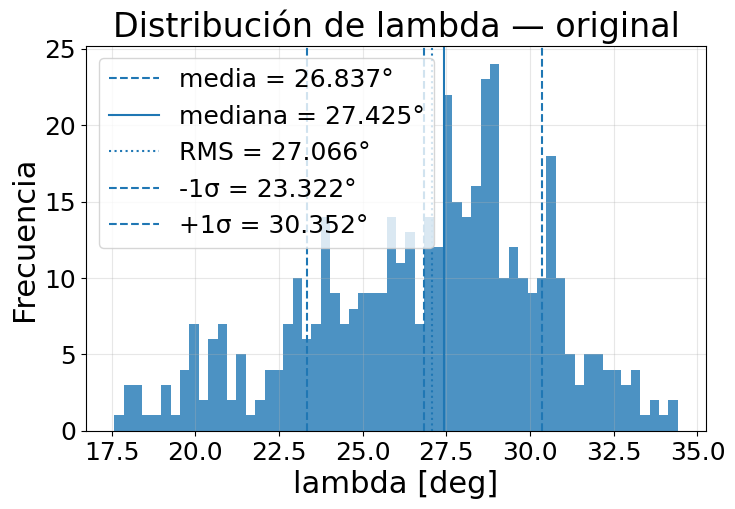

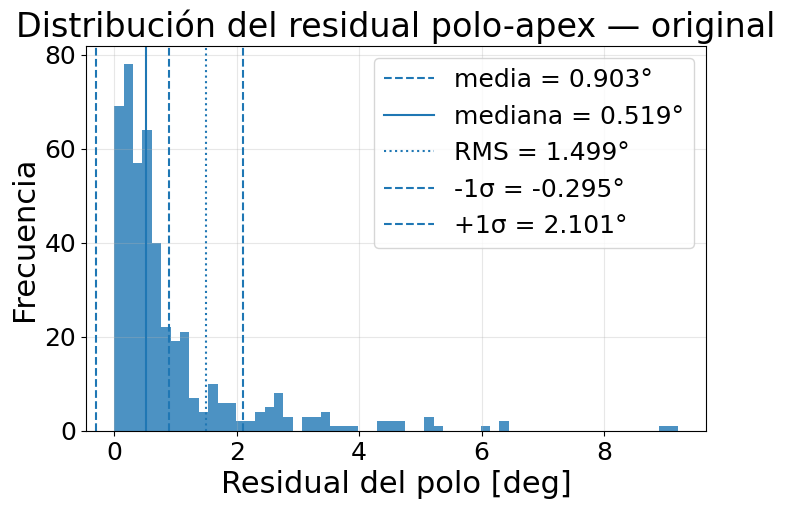

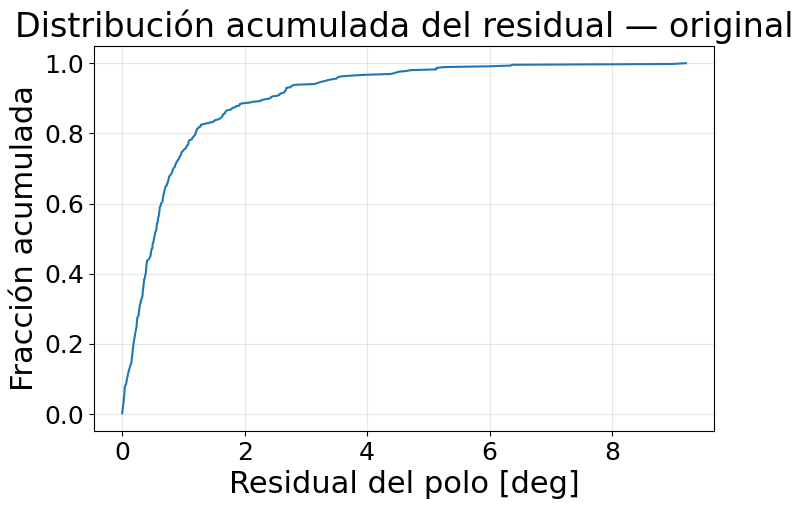

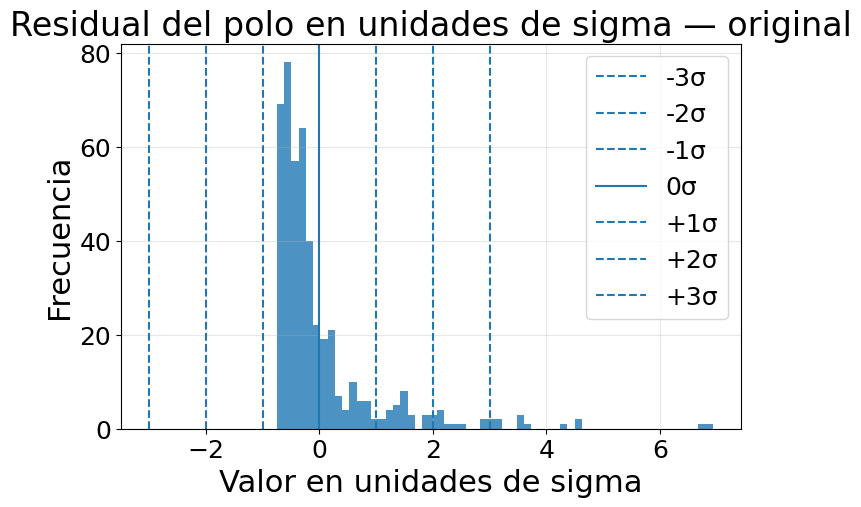

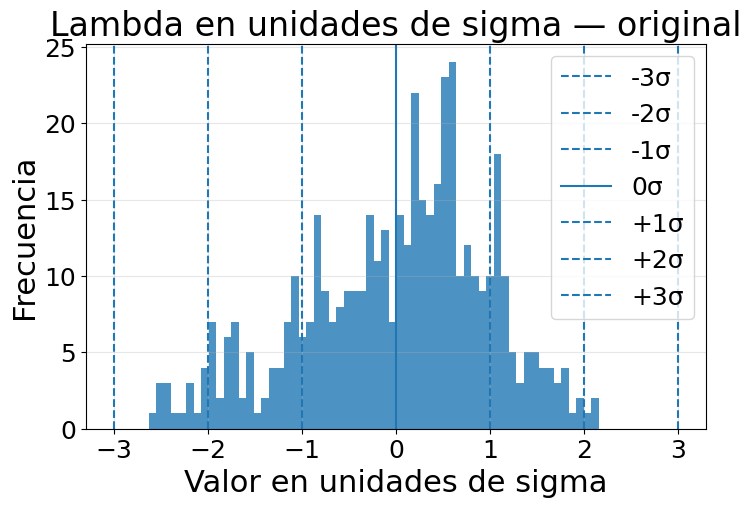

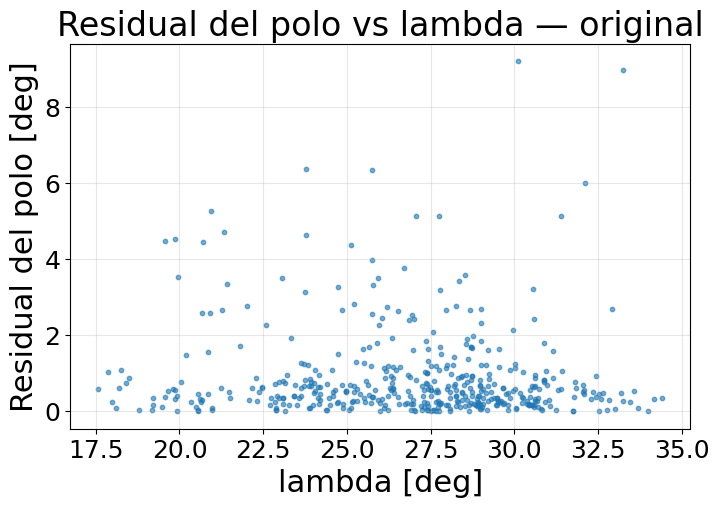

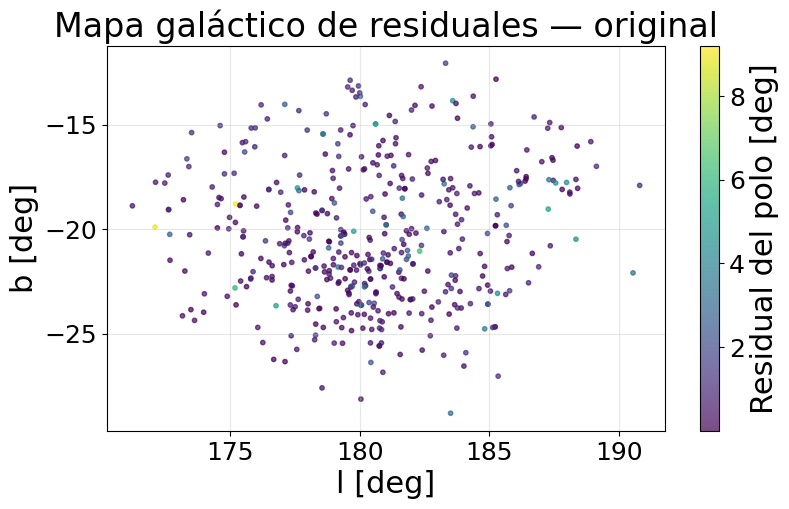

In [201]:
plot_apex_diagnostics(
    df_diag,
    prefix="original",
    weight_col=None,
    bins=60,
)


=== pairwise: lambda estrella-apex ===
n                         : 455
mean [deg]                : 27.222728
median [deg]              : 27.814781
std [deg]                 : 3.515600
RMS [deg]                 : 27.448300
robust sigma MAD [deg]    : 3.357496
q16 [deg]                 : 23.545965
q84 [deg]                 : 30.694339
68% half-width [deg]      : 3.574187
min [deg]                 : 17.963111
max [deg]                 : 34.803797

=== pairwise: residual polo-apex ===
n                         : 455
mean [deg]                : 0.894554
median [deg]              : 0.491712
std [deg]                 : 1.205468
RMS [deg]                 : 1.500062
robust sigma MAD [deg]    : 0.478080
q16 [deg]                 : 0.142591
q84 [deg]                 : 1.582161
68% half-width [deg]      : 0.719785
min [deg]                 : 0.001851
max [deg]                 : 9.288587


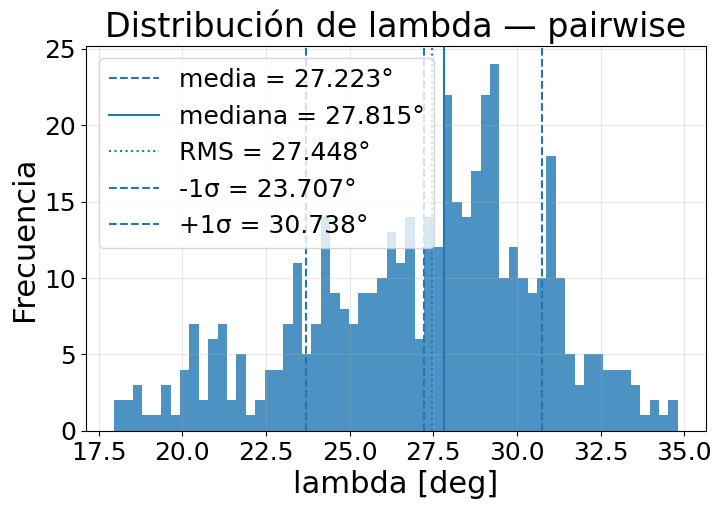

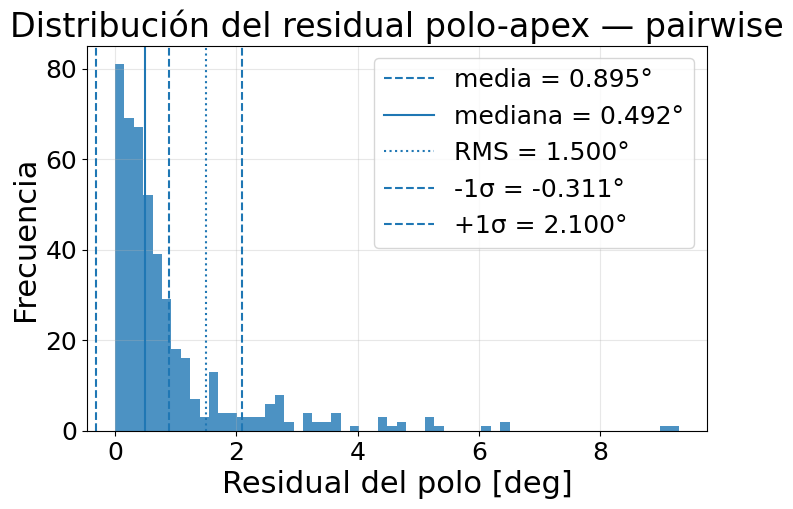

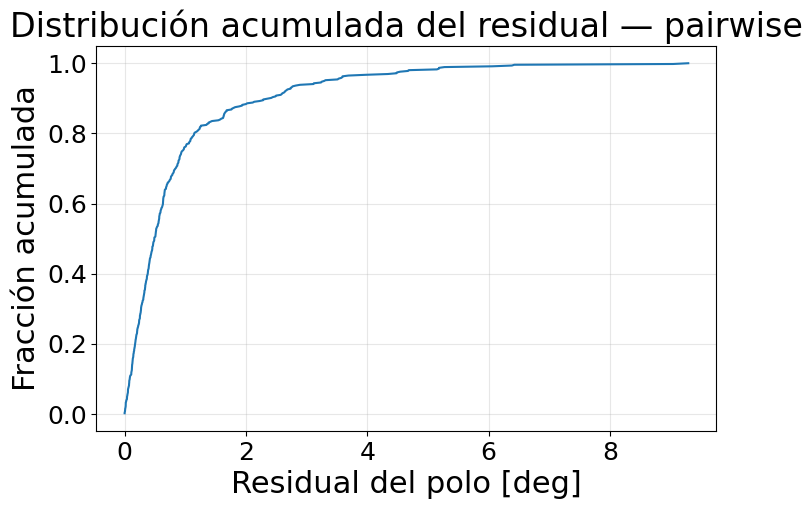

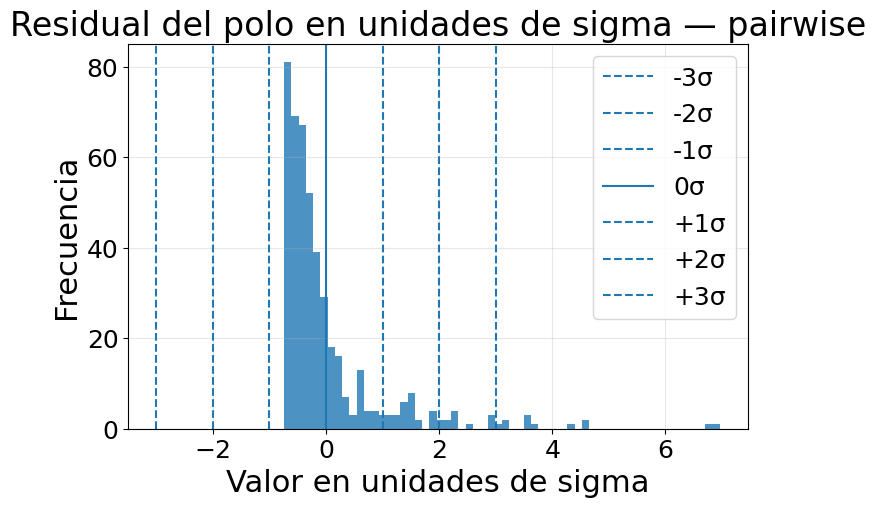

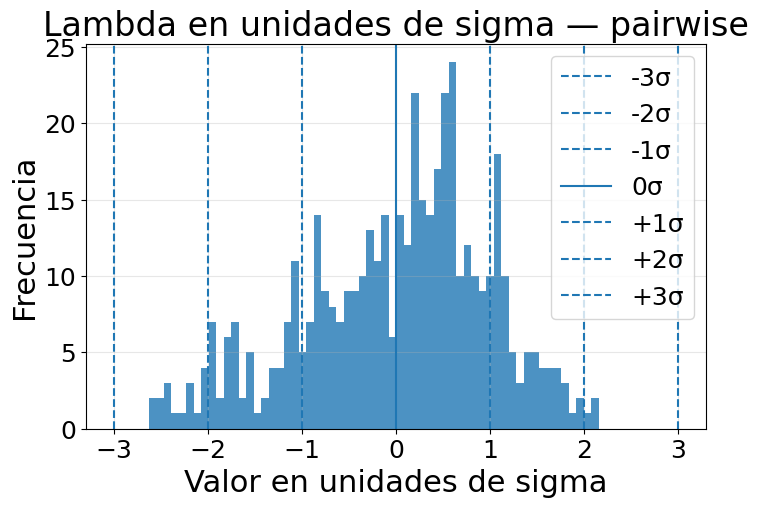

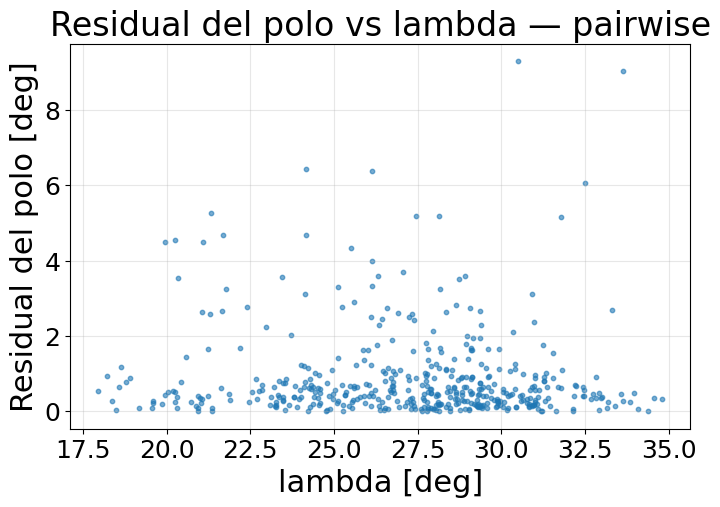

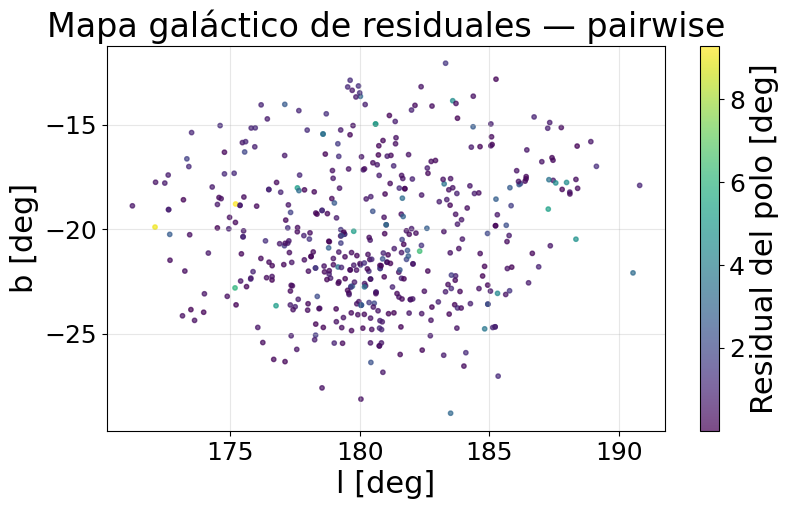

In [202]:
plot_apex_diagnostics(
    df_diag,
    prefix="pairwise",
    weight_col=None,
    bins=60,
)


=== Pairwise: residual candidatos apex ===
n                         : 103285
mean [deg]                : 16.744696
median [deg]              : 8.117352
std [deg]                 : 20.184669
RMS [deg]                 : 26.226050
robust sigma MAD [deg]    : 9.121879
q16 [deg]                 : 2.134910
q84 [deg]                 : 33.513150
68% half-width [deg]      : 15.689120
min [deg]                 : 0.017417
max [deg]                 : 89.998332


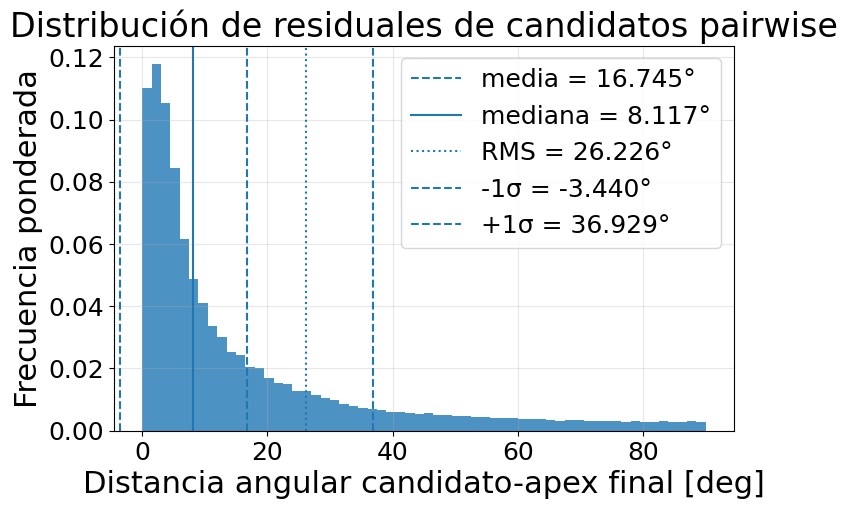

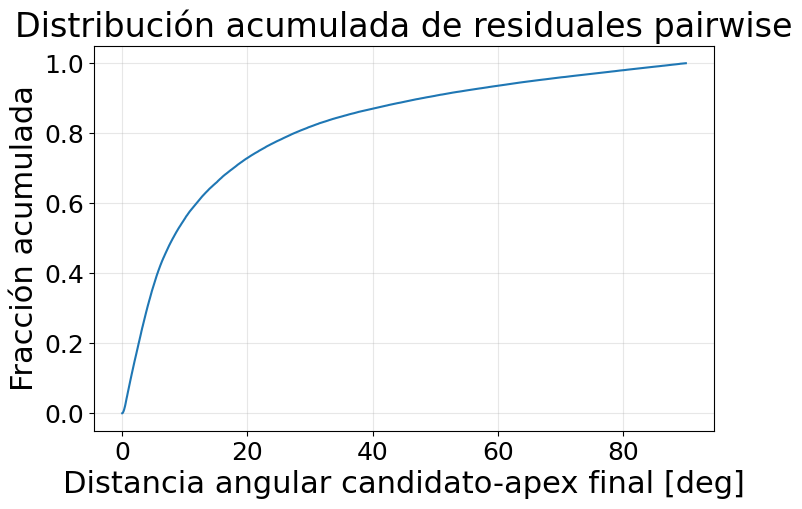

In [203]:
plot_pairwise_candidate_diagnostics(
    pairwise_result,
    bins=60,
)

In [204]:
compare_two_apex_results(
    original_result,
    pairwise_result,
    name_a="original",
    name_b="pairwise",
)


=== Comparación de apex ===
original apex l,b [deg] : 201.910397, -3.741593
pairwise apex l,b [deg] : 202.226841, -3.512717
Diferencia direccional [deg] : 0.390026
Diferencia axial [deg]       : 0.390026

Métricas comparables:
rms_pole_residual_deg
  original: 1.499127009182947
  pairwise: 1.5000619427500723
median_pole_residual_deg
  original: 0.5194663910629254
  pairwise: 0.49171234046752516
toward_apex_fraction
  original: 1.0
  pairwise: 1.0
